# Plotting mapping on extended atlas

In this notebook I plot the scRNA-seq data of the newly generated Eomes multiome data and the published (Nature Cell Biology) data on the haematopoeietic landscapes of Ivan's extended gastrulation atlas.

In [1]:
suppressPackageStartupMessages({
   # library(tidyr)
    library(ggrastr)
    library(viridis)
    library(gridExtra)
})

here::i_am("rna/processing/1_create_seurat_rna.R")

source(here::here("settings.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
## I/O ##
io$haem_landscape = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping_ivan'
io$mapping_ivan = file.path(io$haem_landscape, 'LukesGrantMapping')
io$plotdir = file.path(io$basedir, 'results/rna/mapping_ivan/plots')
dir.create(io$plotdir, recursive = TRUE)

Warning message in dir.create(io$plotdir, recursive = TRUE):
“'/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/rna/mapping_ivan/plots' already exists”


In [3]:
options(repr.plot.width=15, repr.plot.height=8)
# function for mapping on fa
plot_mapping = function(query, atlas){
    atlas = as.data.table(colData(atlas))

    query_full = query %>%
                        merge(atlas[,c('cell', 'Dim1', 'Dim2')], by.x='closest.cell_ext', by.y='cell') %>% # add FA of closest cells
                        setnames('day', 'Day')    

    # Get labels at centre of group
    labels = atlas %>% 
                .[, N:=.N, by=celltype.clustering] %>% # number of cells per celltype
                .[N>.N/100,] %>% # label only celltypes that are more than 1% of cells
                .[,list(median(Dim1), median(Dim2)), 
                        by=celltype.clustering] %>% # Determine median position on UMAP
                setnames(c('V1', 'V2'), c('Dim1', 'Dim2'))

    # Plot atlas FA
    p1 = ggplot(atlas, aes(Dim1, Dim2, col = celltype.clustering)) + 
        rasterise(geom_point(alpha = 0.5, size = 0.5), dpi=300) + 
        ggrepel::geom_text_repel(data=labels, 
                                    aes(Dim1, Dim2, label=celltype.clustering), 
                                    col='black', size = 3.5,
                                    max.overlaps=Inf, 
                                    fontface = "bold", 
                                    box.padding = 0.8, 
                                    show.legend = FALSE) + # adds text labels
        scale_color_manual(values=opts$celltype_ext.colors) + 
        theme_void() + 
        theme(text = element_text(size = 20), 
             legend.position='none')

    # Plot mapping
    p2 = ggplot(query_full, aes(Dim1, Dim2, col = Day)) + 
        rasterise(geom_point(data=atlas, aes(Dim1, Dim2), col='gray80'), dpi=300) + 
        rasterise(geom_point(alpha = 0.5, size = 1), dpi=500) +
        scale_color_viridis(discrete=TRUE) + 
        guides(colour = guide_legend(override.aes = list(size=7, alpha=1))) +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(strip.text.x = element_text(size = 20),
              legend.title = element_text(size=15),
              legend.text = element_text(size=15))

    options(repr.plot.width=20, repr.plot.height=8)
    return(grid.arrange(p1, p2, ncol=2, widths = c(1,2.3)))
}

# Multiome

In [7]:
eomes_multiome_mapping = readRDS(file.path(io$mapping_ivan, "eomes_multiome/multiome2atlas.rds"))
eomes_multiome_meta = fread(file.path(io$mapping_ivan, "eomes_multiome/sample_metadata_after_mapping.txt"))

In [8]:
rename = c("wt" = "WT",
  "eomes_ko" = "Eomes KO")

eomes_multiome_meta = merge(eomes_multiome_meta,
                            as.data.table(eomes_multiome_mapping) %>% # merge metadata with ext mapping
                                setnames(c('cell','celltype.mapped_ext', 'stage.mapped_ext', 'closest.cell_ext')) %>% # make new colnames
                                .[,cell:=gsub('map_', '', cell)], by='cell') %>% # make cell names compatible
                                .[,genotype:=stringr::str_replace_all(genotype, rename)] %>%
                                .[pass_rnaQC==TRUE & doublet_call==FALSE,] # keep cells that pass QC


# NCB data

In [44]:
eomes_ncb_mapping_D4WT = as.data.table(readRDS(file.path(io$mapping_ivan, "eomes_public/GSM4153428_scRNA_WT_D4.mapping.rds"))) %>%
                                  .[,cell:=gsub('map', 'D4WT', gsub('-1', '', cell))] 
eomes_ncb_mapping_D5WT = as.data.table(readRDS(file.path(io$mapping_ivan, "eomes_public/GSM4153429_scRNA_WT_D5.mapping.rds"))) %>%
                                  .[,cell:=gsub('map', 'D5WT', gsub('-1', '', cell))]
eomes_ncb_mapping_D4MT = as.data.table(readRDS(file.path(io$mapping_ivan, "eomes_public/GSM4153430_scRNA_Eomes_null_D4.mapping.rds"))) %>%
                                  .[,cell:=gsub('map', 'D4MT', gsub('-1', '', cell))]
eomes_ncb_mapping_D5MT = as.data.table(readRDS(file.path(io$mapping_ivan, "eomes_public/GSM4153431_scRNA_Eomes_null_D5.mapping.rds"))) %>%
                                  .[,cell:=gsub('map', 'D5MT', gsub('-1', '', cell))]


eomes_ncb_mapping = rbind(eomes_ncb_mapping_D4WT, eomes_ncb_mapping_D5WT, eomes_ncb_mapping_D4MT, eomes_ncb_mapping_D5MT)%>%
                                  setnames(c('cell','celltype.mapped_ext', 'stage.mapped_ext', 'closest.cell_ext')) # new colnames

In [45]:
eomes_ncb_meta = as.data.table(readRDS(file.path(io$mapping_ivan, "eomes_public/integrated.rds"))@meta.data, keep.rownames=TRUE) %>%
                                    setnames('rn', 'cell') %>%
                                    .[, cell:=gsub('-1', '', cell)]

In [46]:
rename = c("MT" = "Eomes KO")
rename_day = c('4' = 'D4',
               '5' = 'D5')

eomes_ncb_meta_full = merge(eomes_ncb_meta, eomes_ncb_mapping, by='cell') %>% 
                                .[,genotype:=stringr::str_replace_all(genotype, rename)] %>%
                                .[,day:=stringr::str_replace_all(day, rename_day)]

### haem_full_landscape mapping

In [9]:
haem_full_landscape = readRDS(file.path(io$haem_landscape, "haem_full_landscape.rds"))

png 
  2

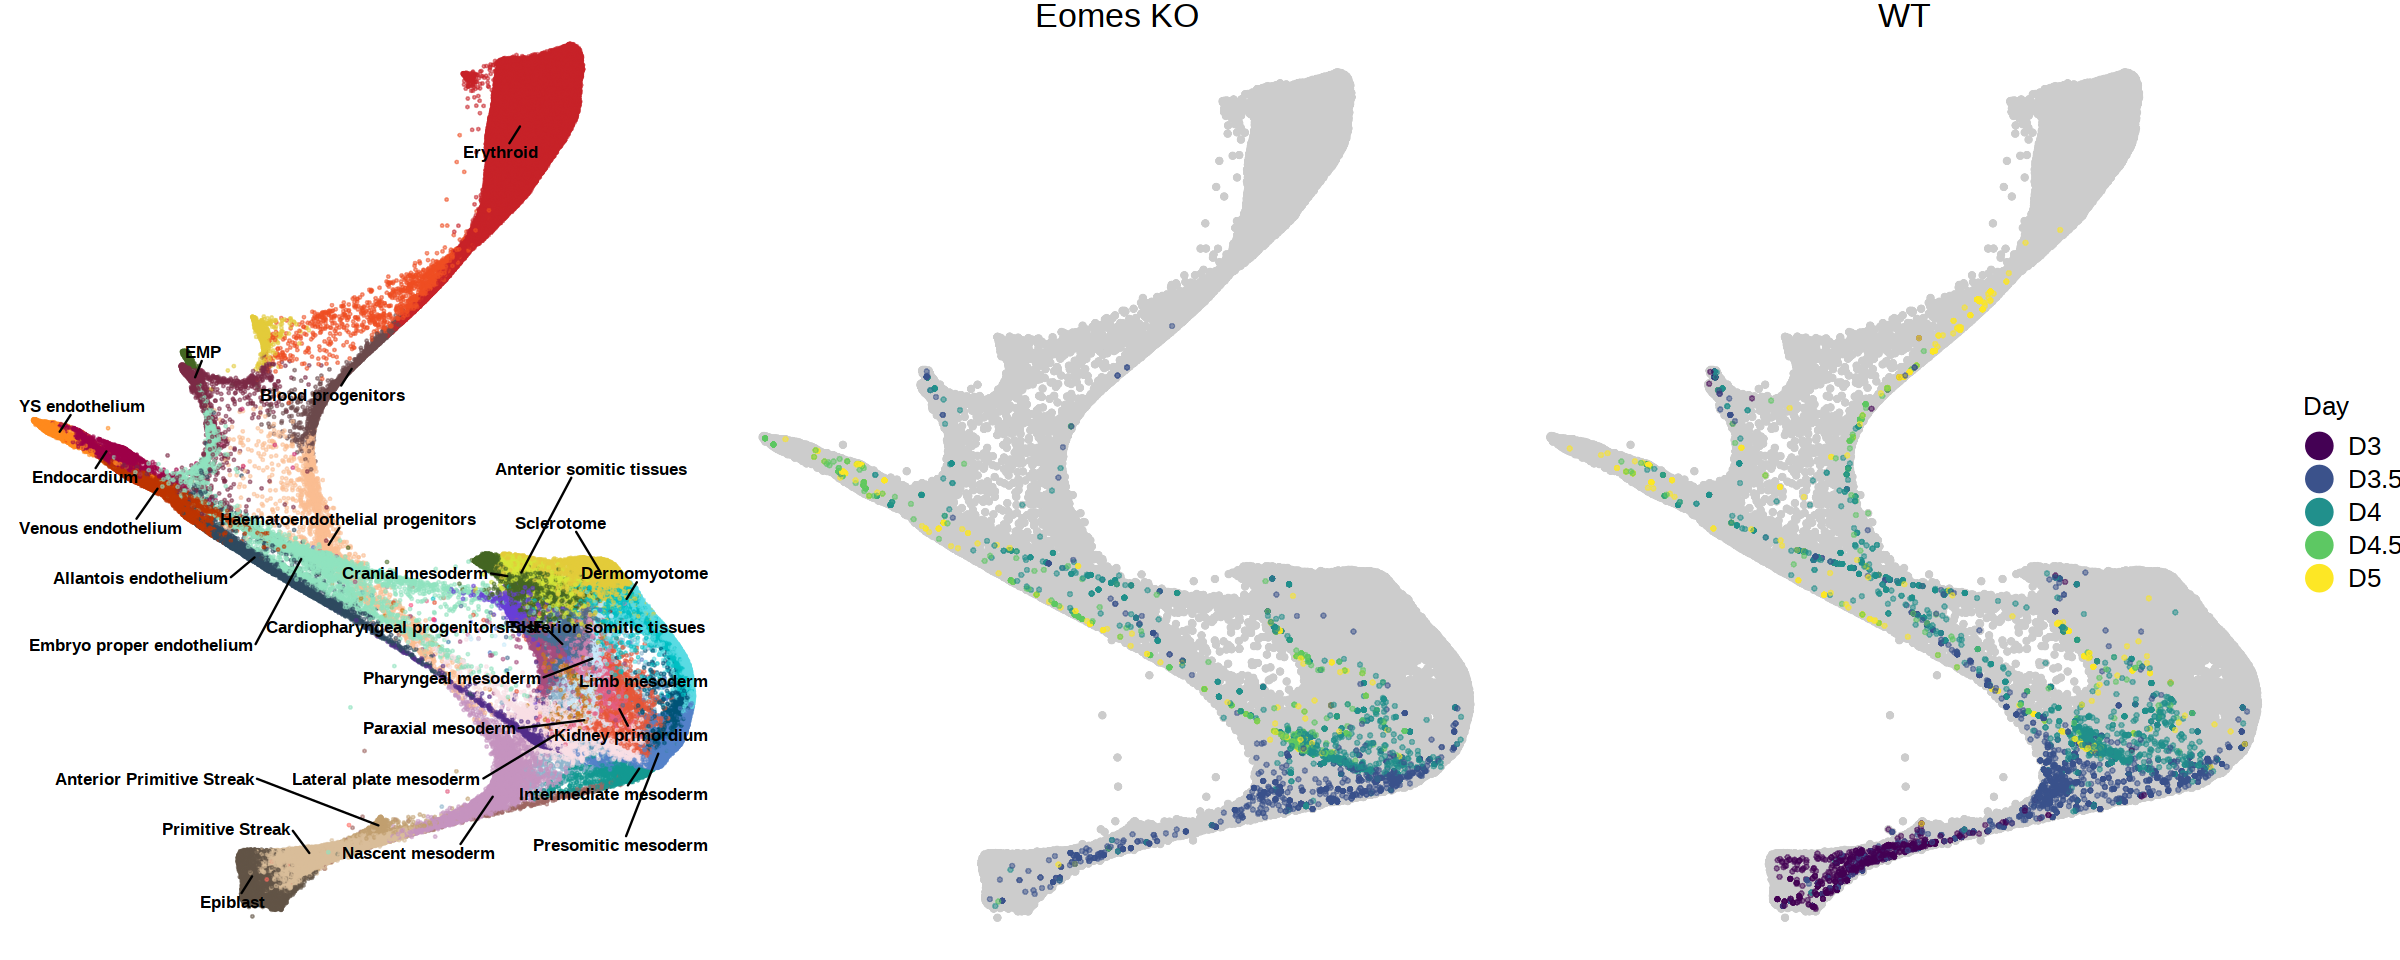

png 
  2

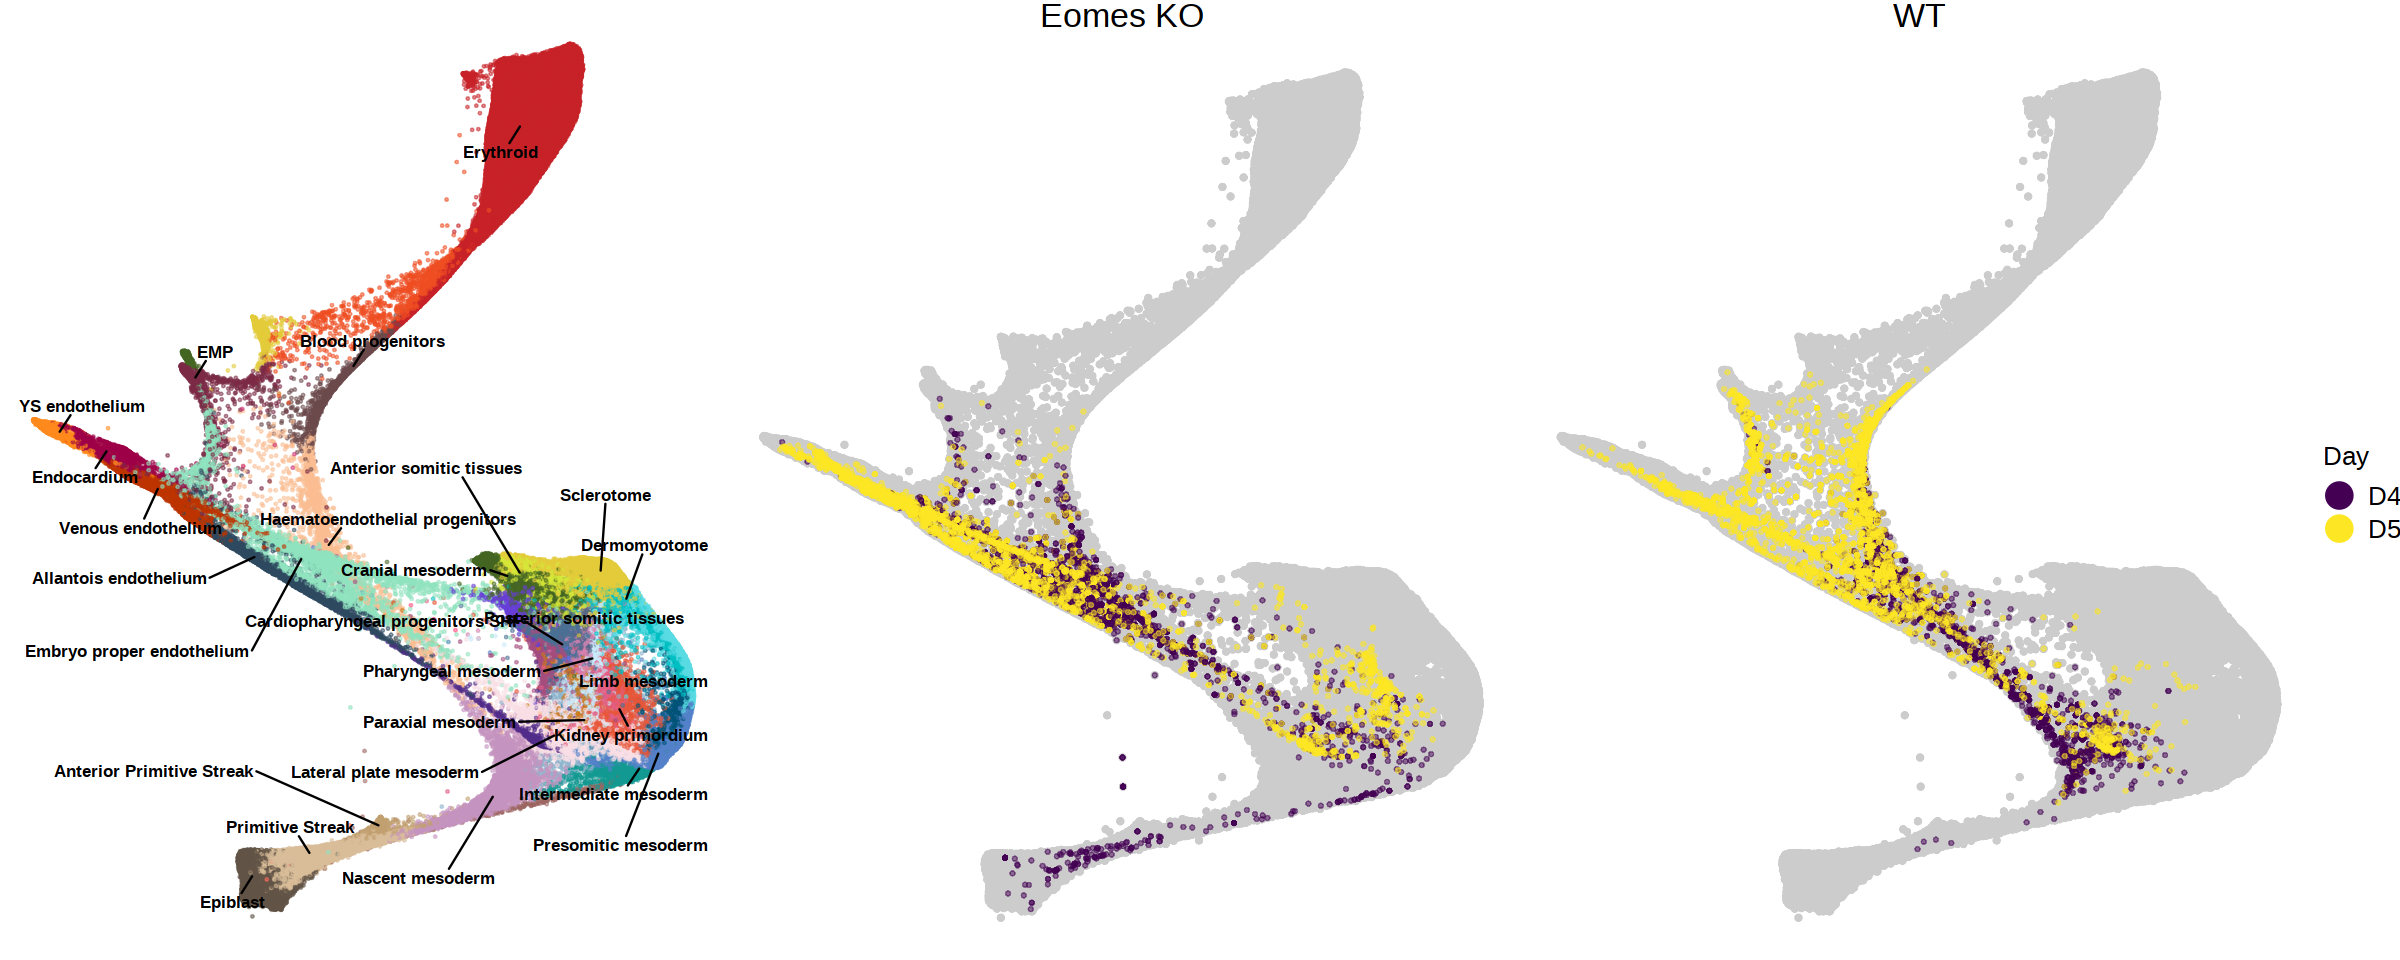

In [10]:
plot = plot_mapping(eomes_multiome_meta, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'multiome_haem_full.pdf'),
    width=20, height=8)
    grid.arrange(plot)
dev.off()


plot = plot_mapping(eomes_ncb_meta_full, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'ncb_haem_full.pdf'),
    width=20, height=8)
        grid.arrange(plot)
dev.off()

### haem_endothelium_landscape mapping

In [11]:
haem_full_landscape = readRDS(file.path(io$haem_landscape, "haem_endothelium_landscape.rds"))

png 
  2

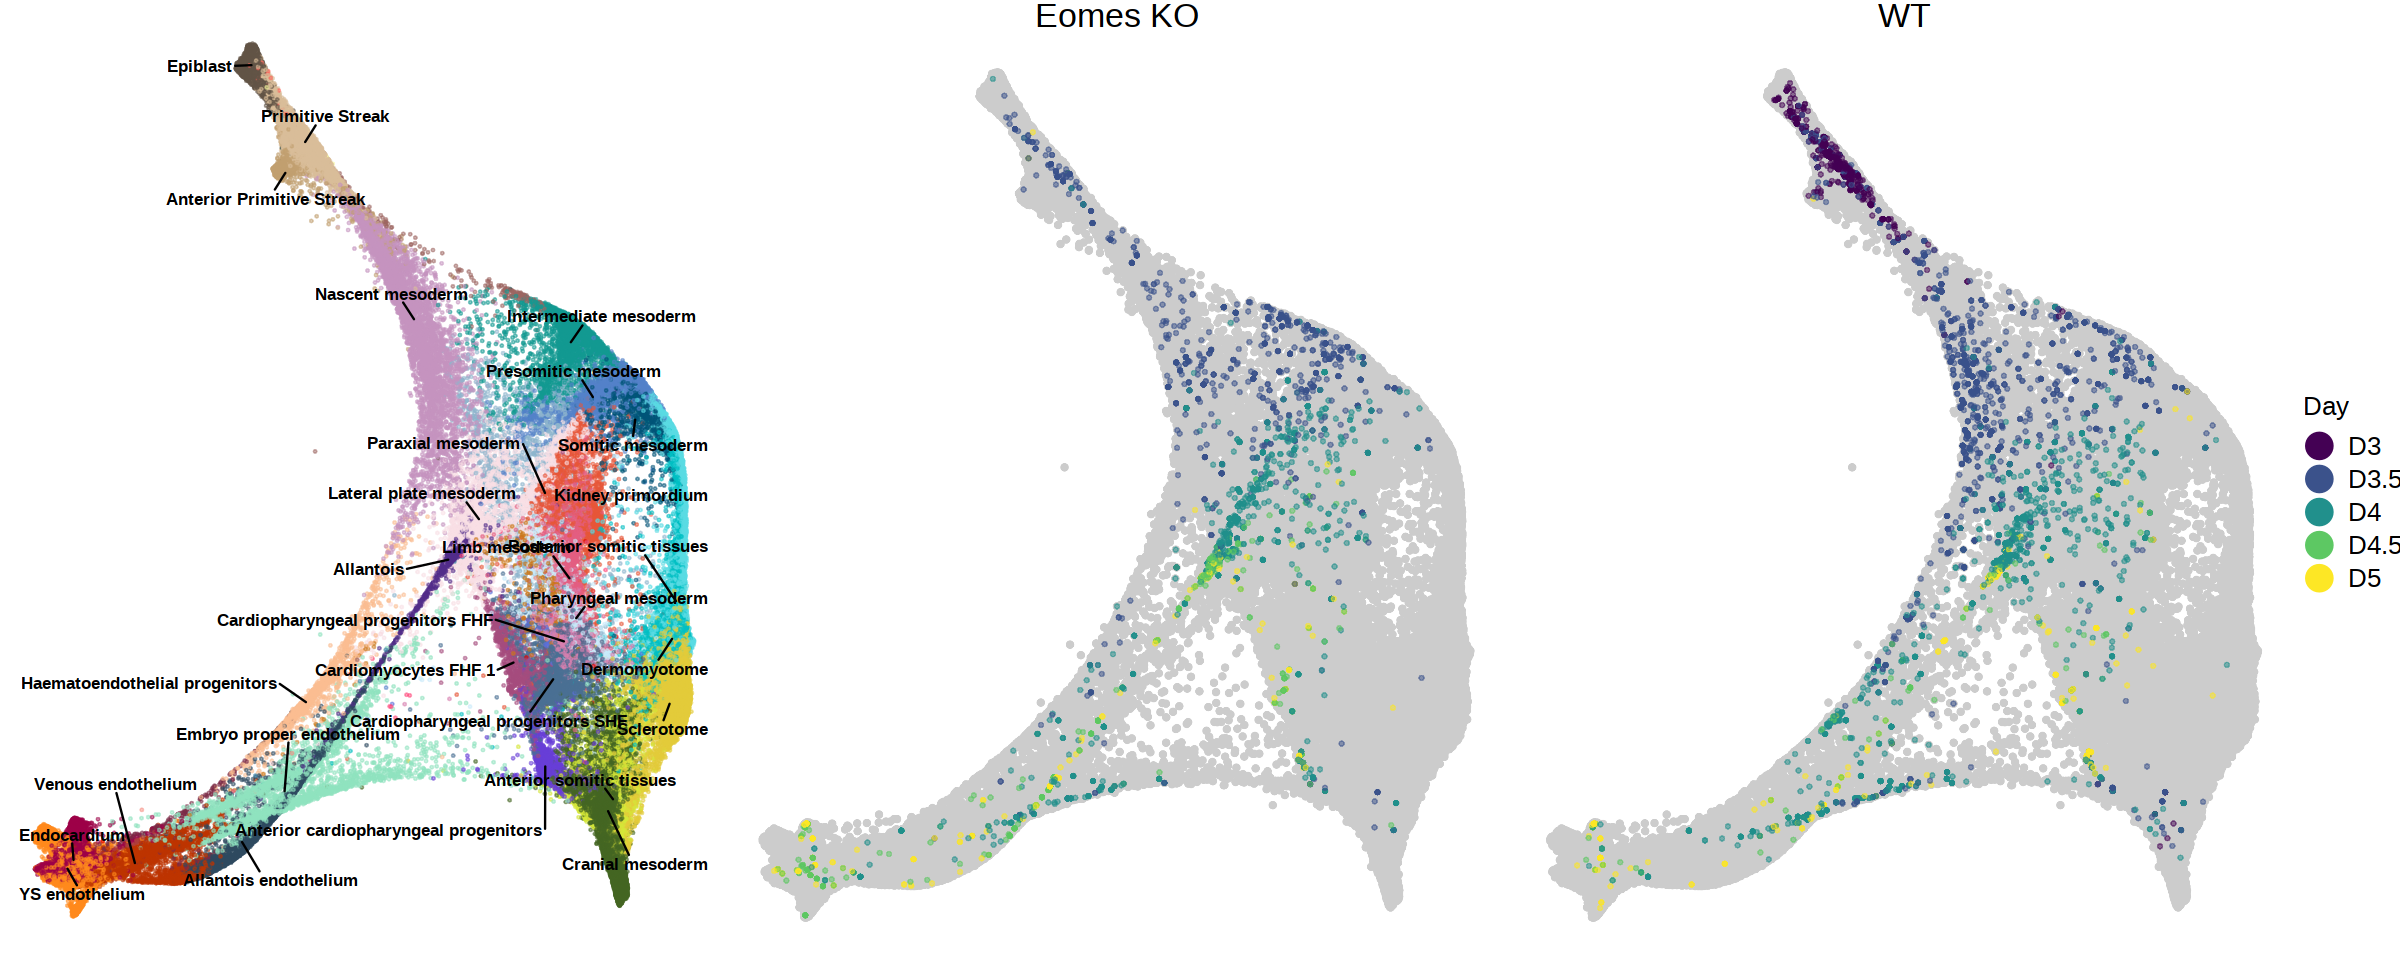

png 
  2

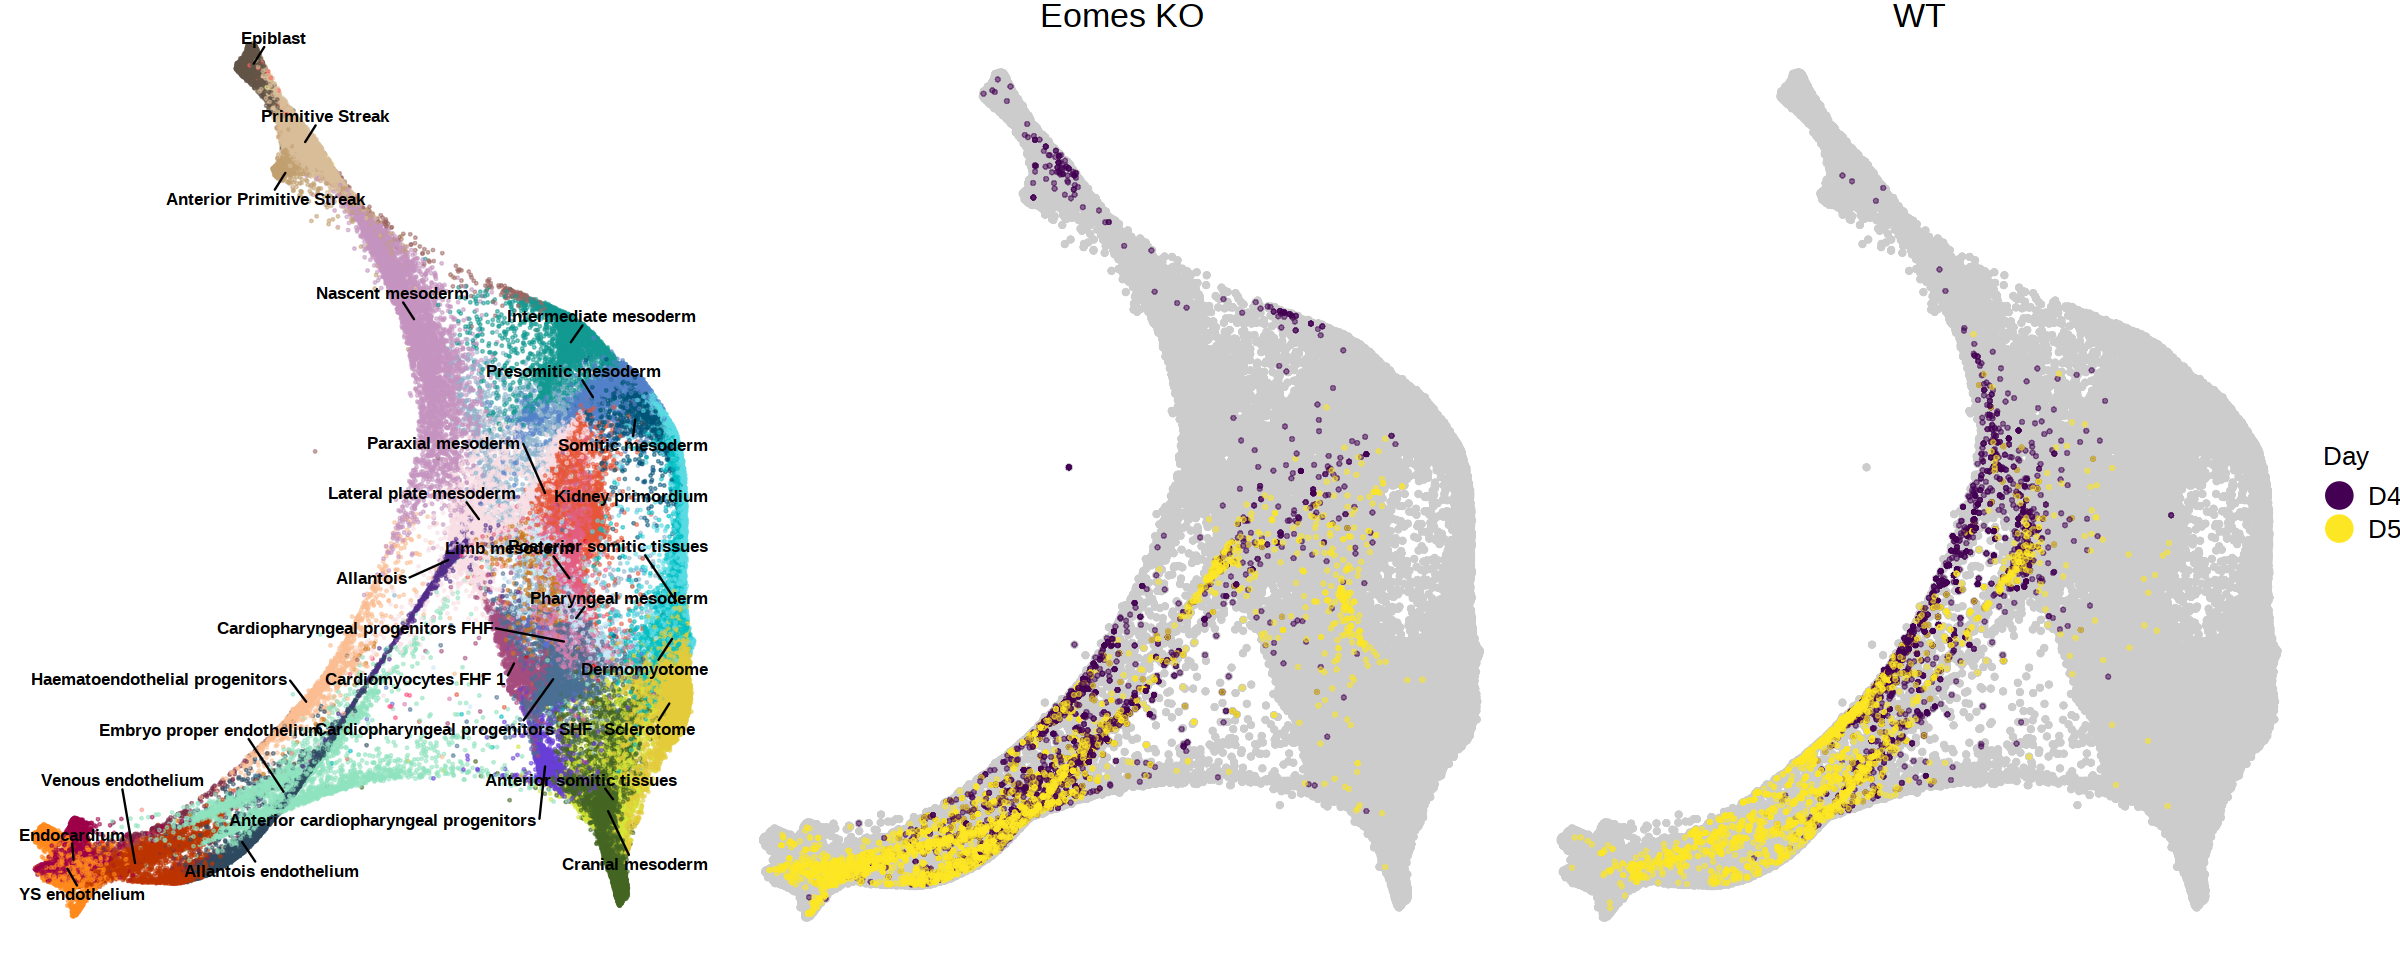

In [12]:
plot = plot_mapping(eomes_multiome_meta, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'multiome_haem_endothelium.pdf'),
    width=20, height=8)
        grid.arrange(plot)
dev.off()

plot = plot_mapping(eomes_ncb_meta_full, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'ncb_haem_endothelium.pdf'),
    width=20, height=8)
        grid.arrange(plot)
dev.off()

### haem_endothelium_landscape mapping

In [14]:
haem_full_landscape = readRDS(file.path(io$haem_landscape, "haem_canonical_landscape.rds"))

png 
  2

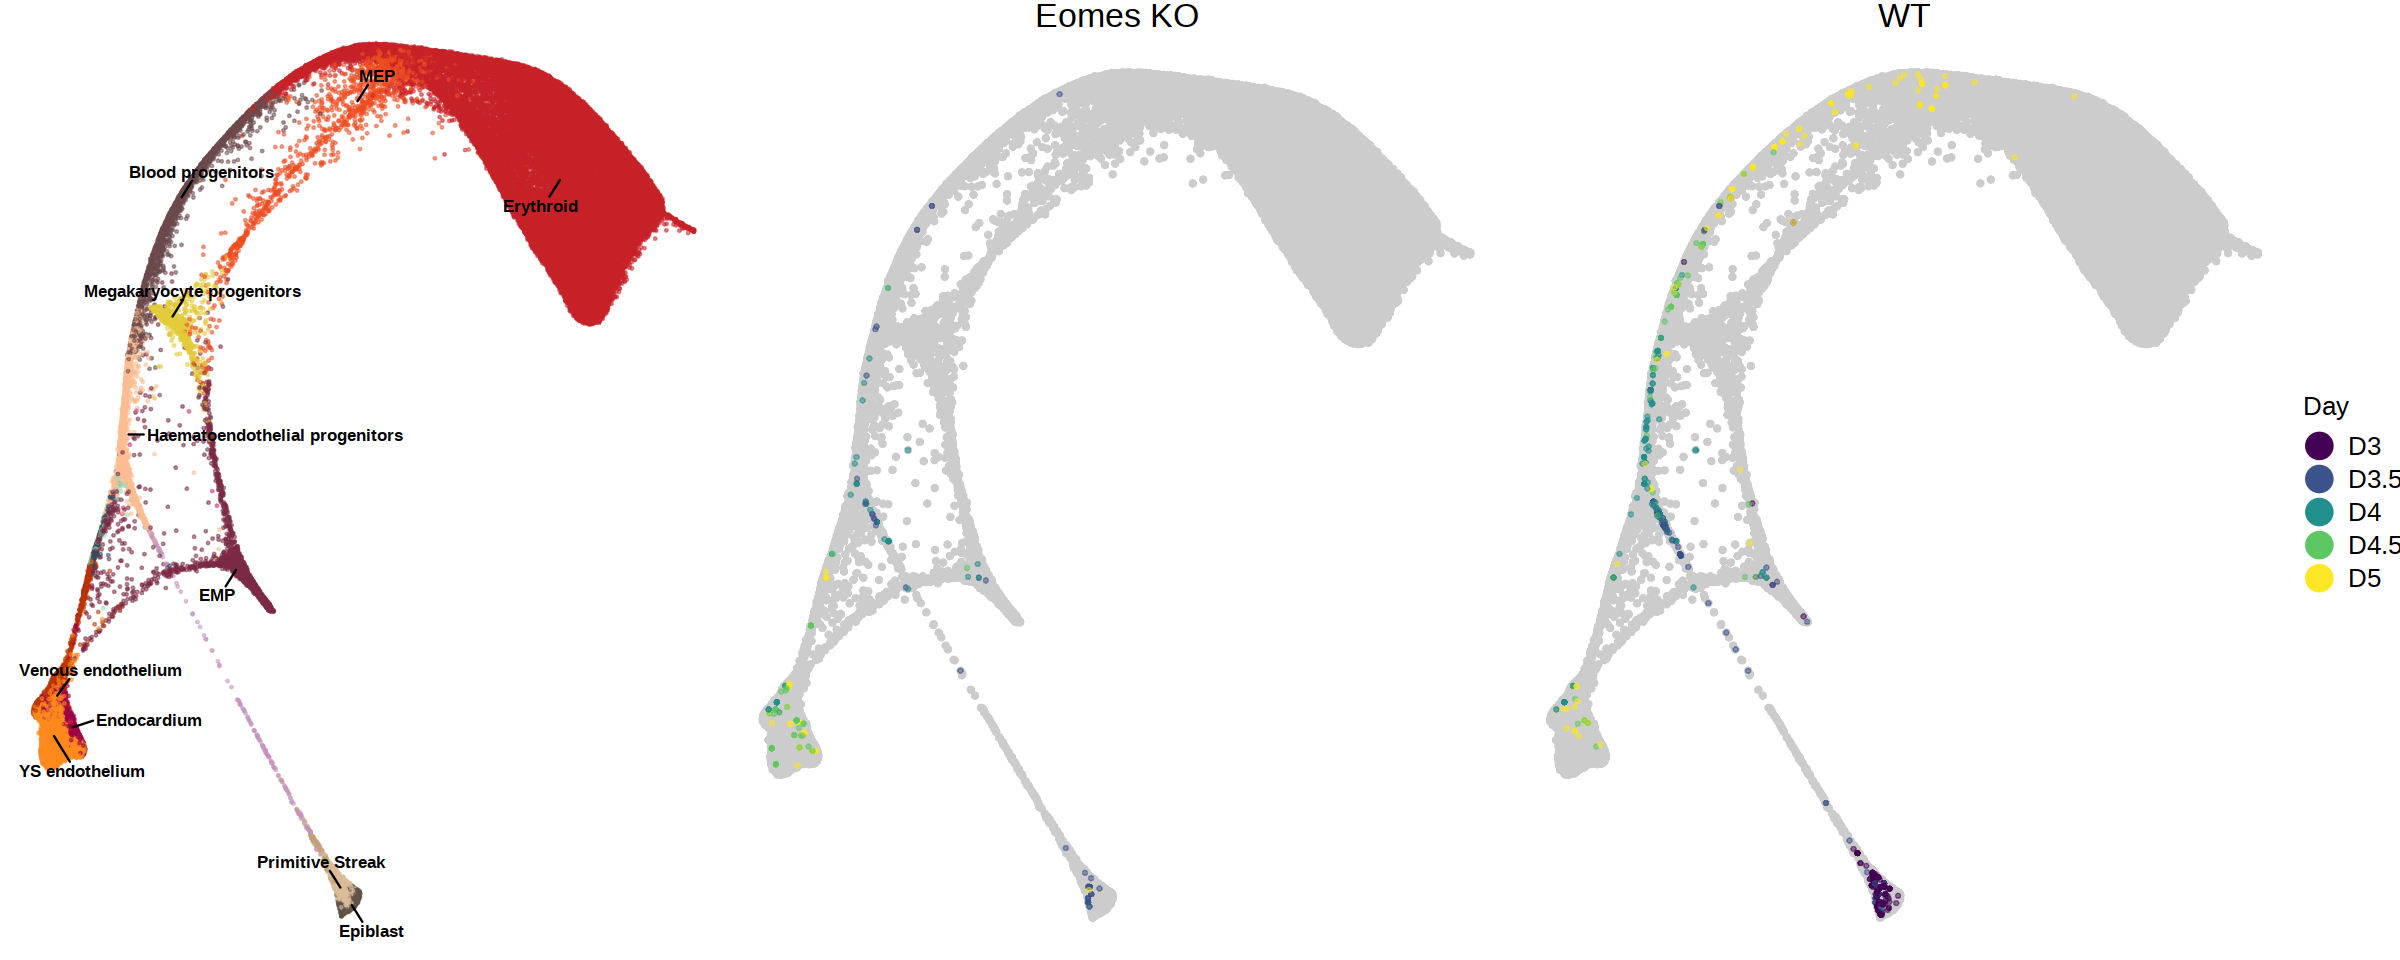

png 
  2

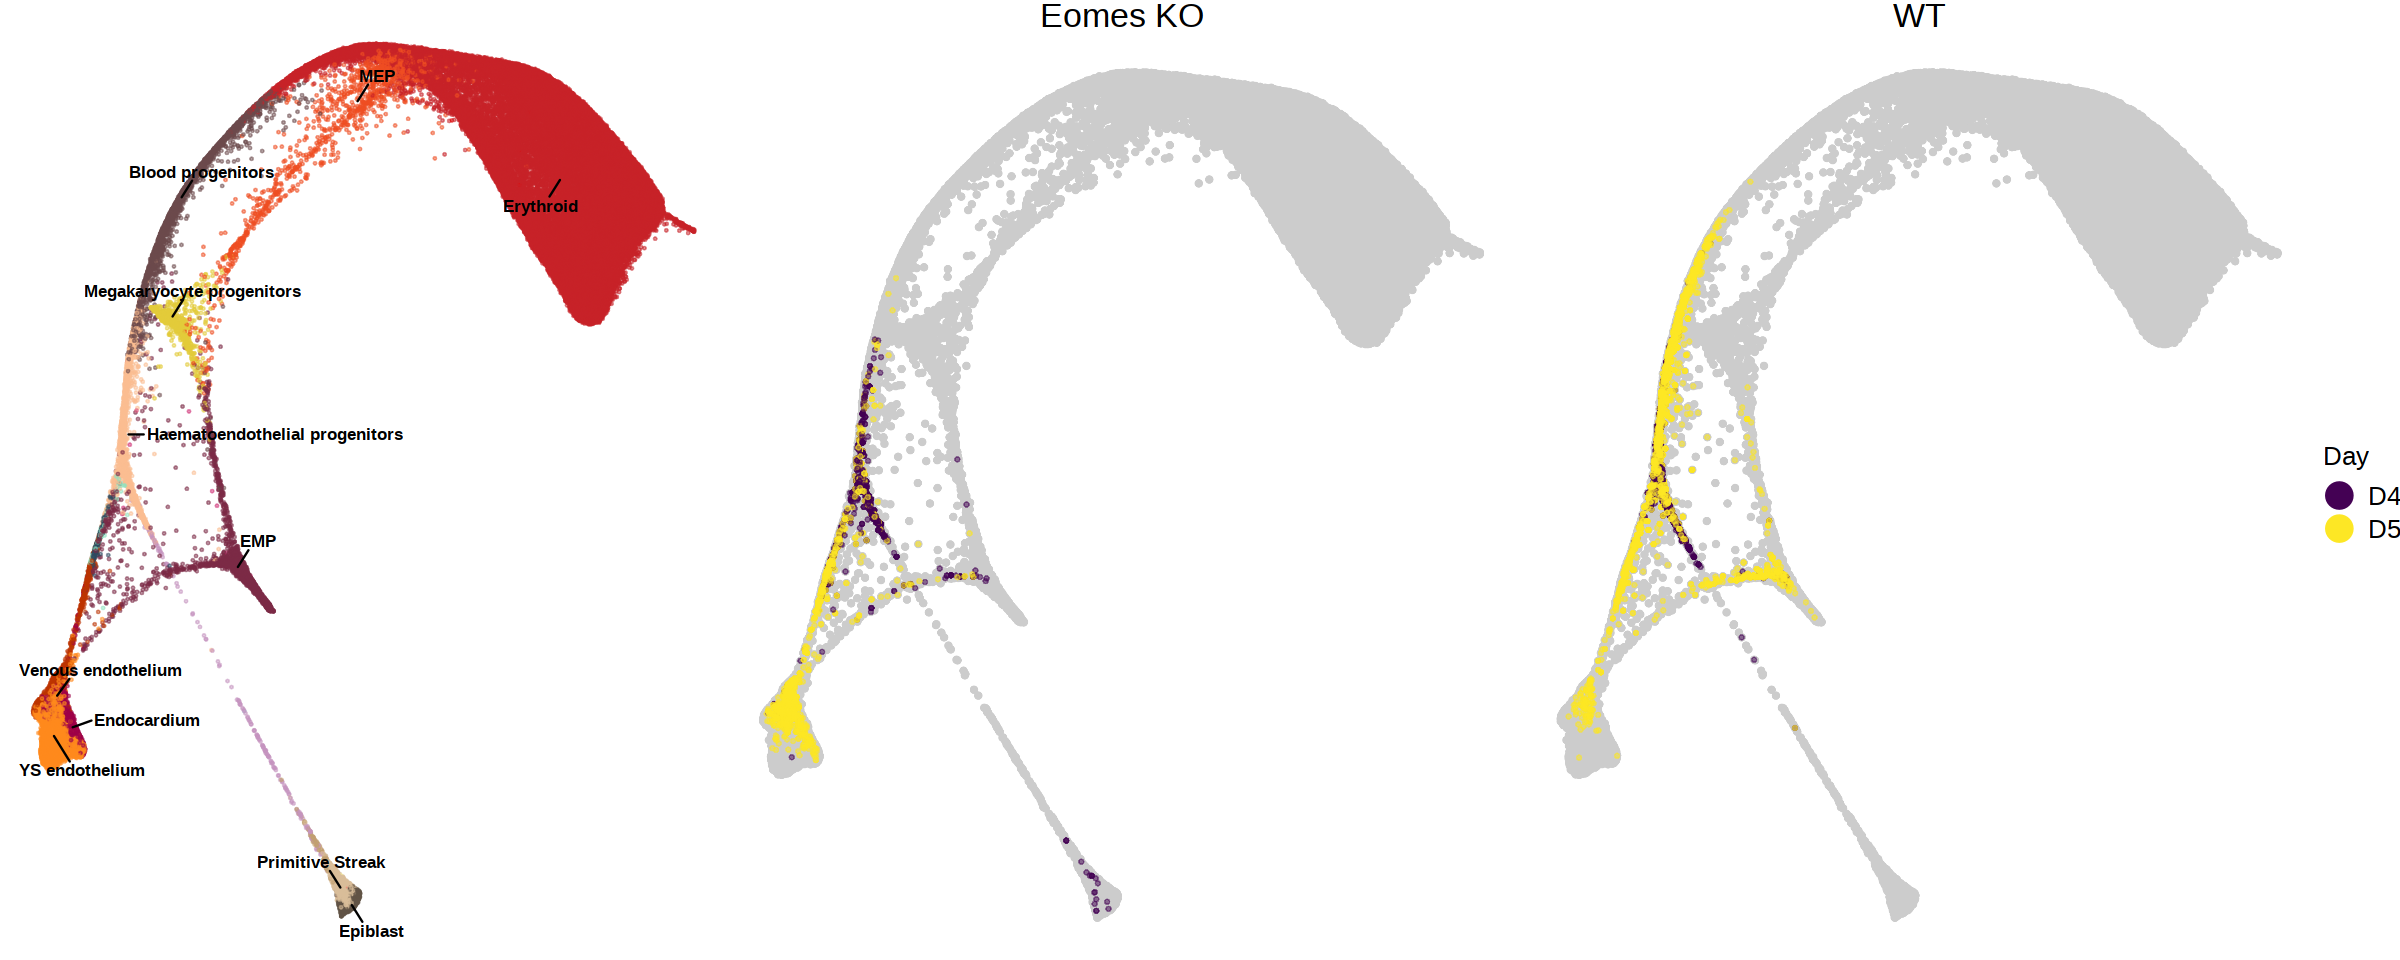

In [14]:
plot = plot_mapping(eomes_multiome_meta, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'multiome_haem_canonical.pdf'),
    width=20, height=8)
        grid.arrange(plot)
dev.off()

plot = plot_mapping(eomes_ncb_meta_full, haem_full_landscape)

pdf(file = file.path(io$plotdir, 'ncb_haem_canonical.pdf'),
    width=20, height=8)
        grid.arrange(plot)
dev.off()

### Mapping on original atlas with timepoint colours

In [60]:
#atlas_meta.dt = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata.txt.gz")
atlas_meta.dt = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/meta.tab")
head(atlas_meta.dt)

cell,barcode,sample,stage,sequencing.batch,theiler,doub.density,doublet,cluster,cluster.sub,⋯,haem_gephiY,haem_subclust,endo_gephiX,endo_gephiY,endo_trajectoryName,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster
<chr>,<chr>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<int>,<int>,⋯,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
cell_1,AAAGGCCTCCACAA,1,E6.5,1,TS9,0.04311420,FALSE,2,4,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cell_2,AACAAACTCGCCTT,1,E6.5,1,TS9,1.12971326,FALSE,12,1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cell_3,AACAATACCCGTAA,1,E6.5,1,TS9,0.00000000,FALSE,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cell_4,AACACTCTCATTCT,1,E6.5,1,TS9,0.08468852,FALSE,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cell_5,AACAGAGAATCAGC,1,E6.5,1,TS9,0.11212055,FALSE,3,7,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
cell_6,AACATATGAATCGC,1,E6.5,1,TS9,1.25470878,FALSE,1,1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 46038 rows containing missing values (geom_point).”


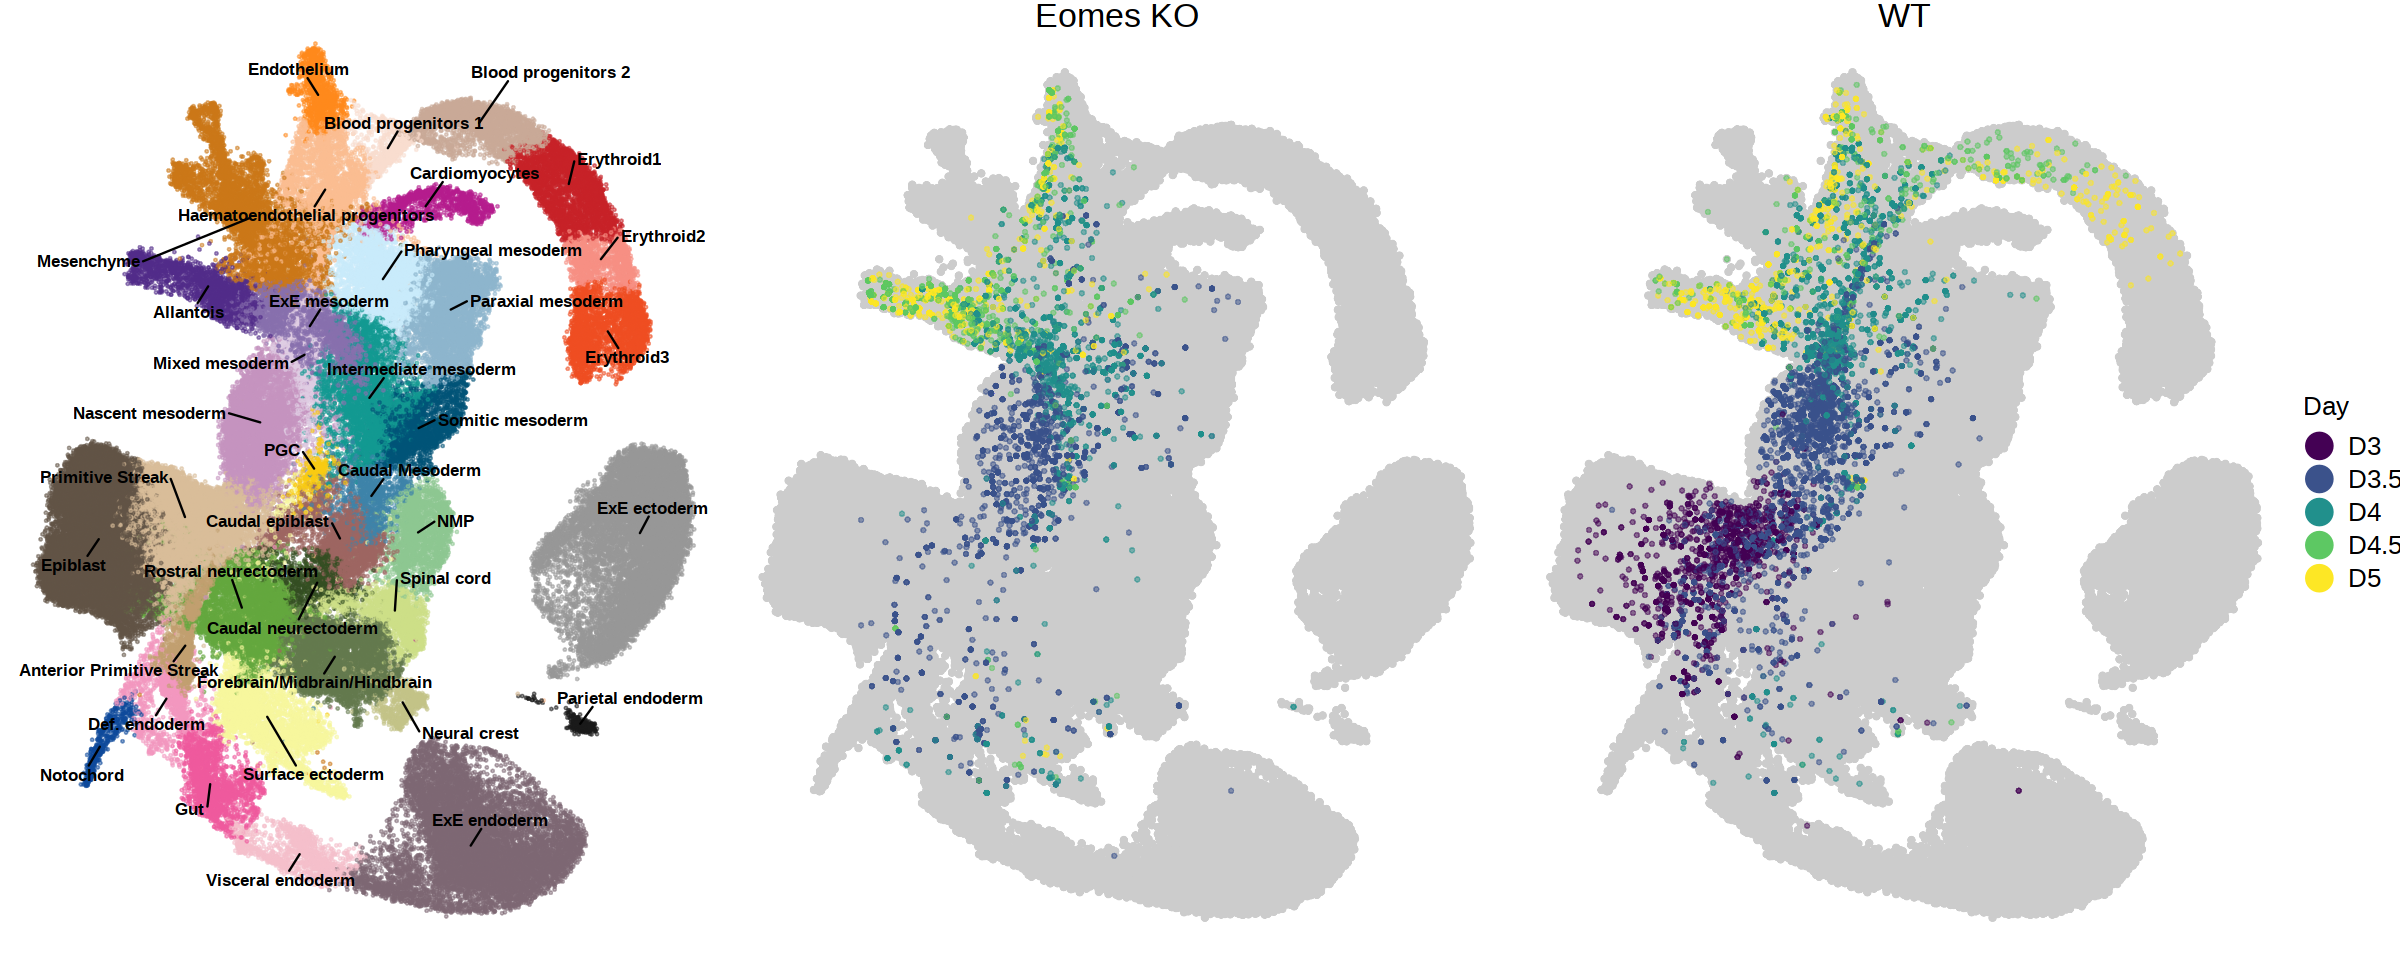

In [67]:
    atlas = atlas_meta.dt
query = eomes_multiome_meta
    query_full = query %>%
                        merge(atlas[,c('cell', 'umapX', 'umapY')], by.x='closest.cell', by.y='cell') %>% # add FA of closest cells
                        setnames('day', 'Day')    

    # Get labels at centre of group
    labels = atlas %>% 
                .[, N:=.N, by=celltype] %>% # number of cells per celltype
               # .[N>.N/100,] %>% # label only celltypes that are more than 1% of cells
                .[,list(median(umapX), median(umapY)), 
                        by=celltype] %>% # Determine median position on UMAP
                setnames(c('V1', 'V2'), c('umapX', 'umapY'))
colors = opts$celltype.colors
names(colors) = gsub('Forebrain Midbrain Hindbrain', 'Forebrain/Midbrain/Hindbrain',gsub('_', ' ', names(colors)))
    # Plot atlas FA
    p1 = ggplot(atlas, aes(umapX, umapY, col = celltype)) + 
        rasterise(geom_point(alpha = 0.5, size = 0.5), dpi=300) + 
        ggrepel::geom_text_repel(data=labels, 
                                    aes(umapX, umapY, label=celltype), 
                                    col='black', size = 3.5,
                                    max.overlaps=Inf, 
                                    fontface = "bold", 
                                    box.padding = 0.8, 
                                    show.legend = FALSE) + # adds text labels
        scale_color_manual(values=colors) + 
        theme_void() + 
        theme(text = element_text(size = 20), 
             legend.position='none')

    # Plot mapping
    p2 = ggplot(query_full, aes(umapX, umapY, col = Day)) + 
        rasterise(geom_point(data=atlas, aes(umapX, umapY), col='gray80'), dpi=300) + 
        rasterise(geom_point(alpha = 0.5, size = 1), dpi=500) +
        scale_color_viridis(discrete=TRUE) + 
        guides(colour = guide_legend(override.aes = list(size=7, alpha=1))) +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(strip.text.x = element_text(size = 20),
              legend.title = element_text(size=15),
              legend.text = element_text(size=15))

    options(repr.plot.width=20, repr.plot.height=8)
    grid.arrange(p1, p2, ncol=2, widths = c(1,2.3))

In [69]:
pdf(file = file.path(io$plotdir, 'multiome_original_atlas.pdf'),
    width=20, height=8)
        grid.arrange(p1, p2, ncol=2, widths = c(1,2.3))
dev.off()

Warning message:
“Removed 23019 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 46038 rows containing missing values (geom_point).”


png 
  2

#### Mapping on original heaem landscape. 
It would be better to redo the mapping by first selecting only cells that belong to the celltypes of this landscape, and only mapping on cells of this landscape.

Warning message:
“Removed 123456 rows containing missing values (geom_point).”
Warning message:
“Removed 30 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 246912 rows containing missing values (geom_point).”
Warning message:
“Removed 30829 rows containing missing values (geom_point).”


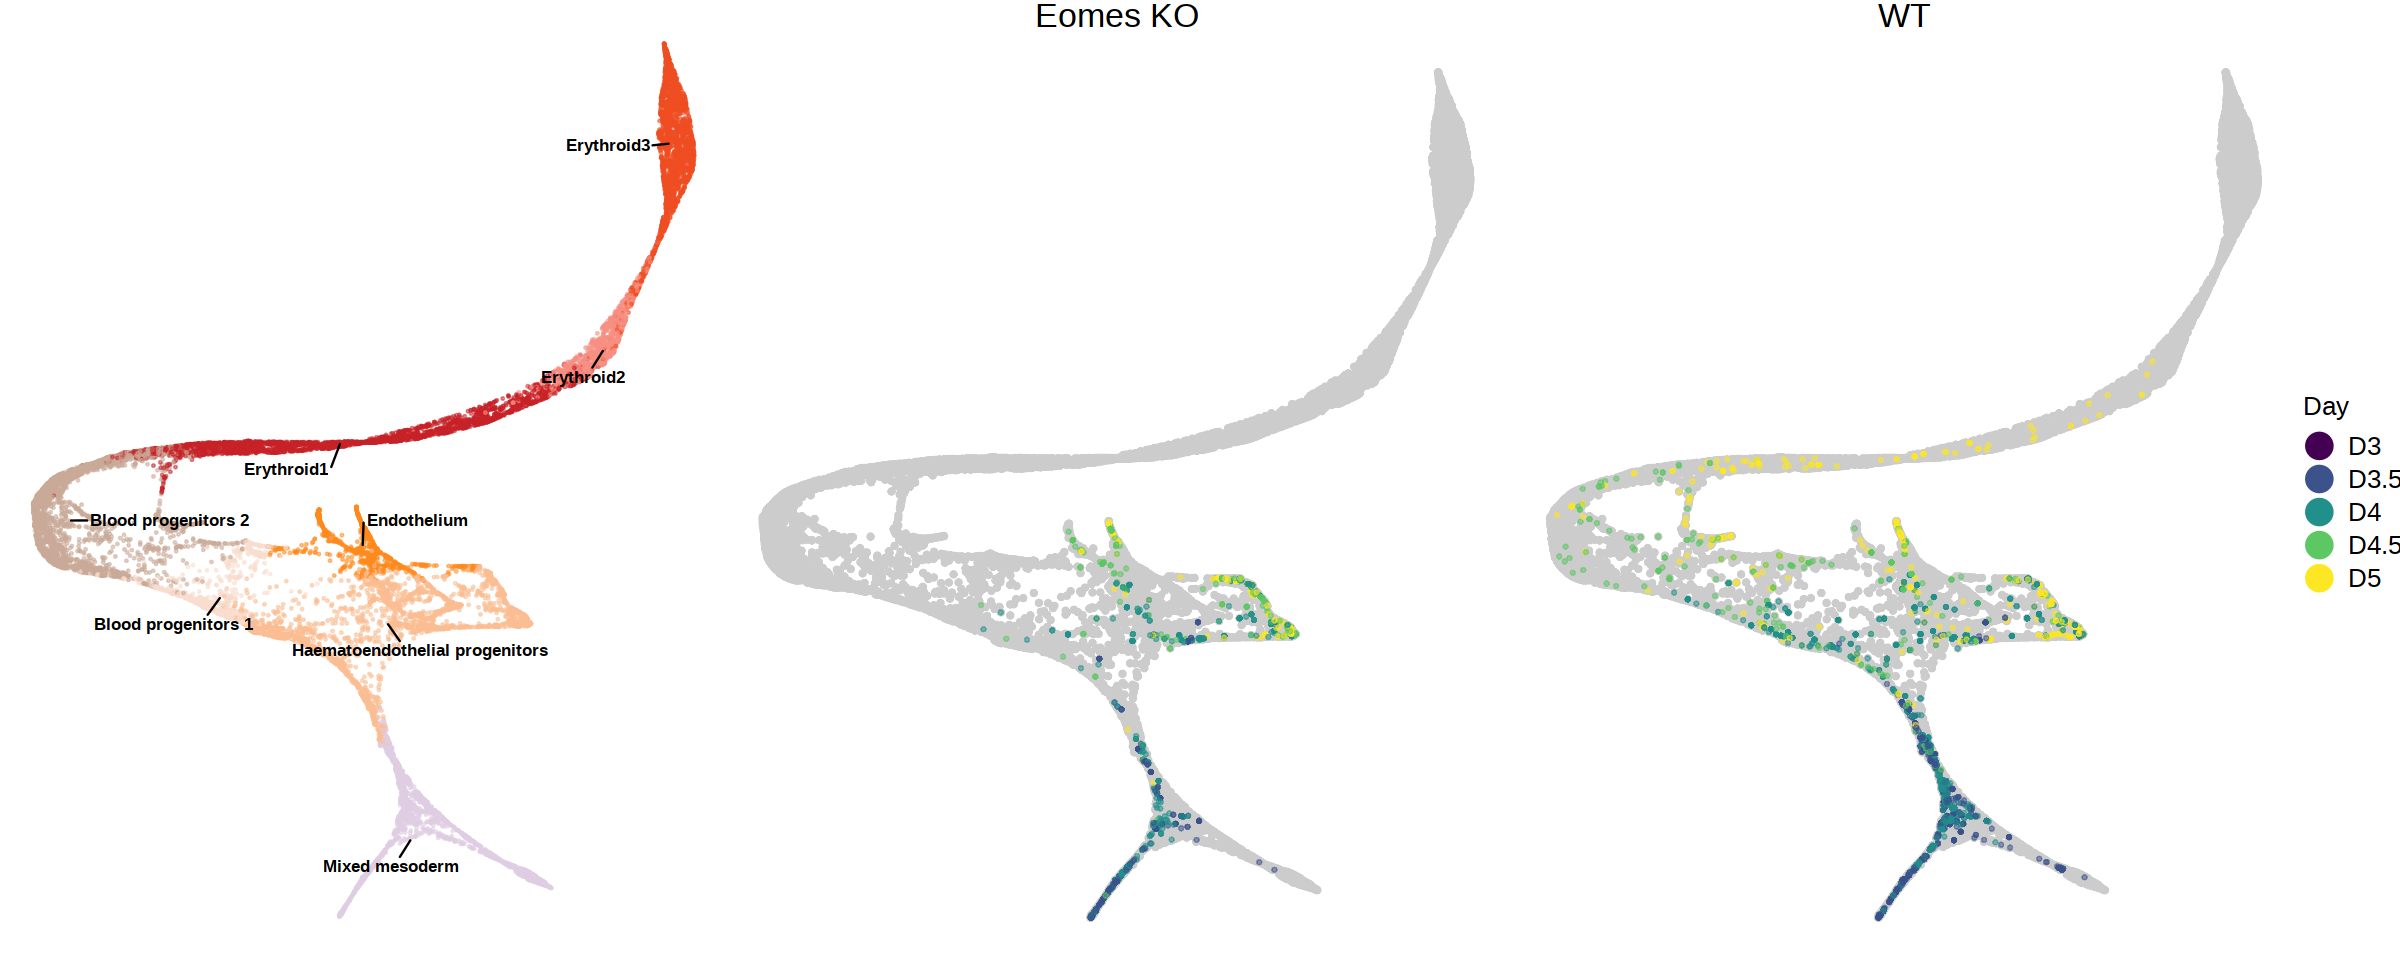

In [43]:
    atlas = atlas_meta.dt[,c('cell', 'celltype','haem_gephiX', 'haem_gephiY'),] %>% setnames(c('haem_gephiX', 'haem_gephiY'), c('umapX','umapY'))
query = eomes_multiome_meta
    query_full = query %>%
                        merge(atlas[,c('cell', 'umapX', 'umapY')], by.x='closest.cell', by.y='cell') %>% # add FA of closest cells
                        setnames(c('day'), c('Day'))    

    # Get labels at centre of group
    labels = atlas %>% 
                .[, N:=.N, by=celltype] %>% # number of cells per celltype
               # .[N>.N/100,] %>% # label only celltypes that are more than 1% of cells
                .[,list(median(umapX), median(umapY)), 
                        by=celltype] %>% # Determine median position on UMAP
                setnames(c('V1', 'V2'), c('umapX', 'umapY'))

    # Plot atlas FA
    p1 = ggplot(atlas, aes(umapX, umapY, col = celltype)) + 
        rasterise(geom_point(alpha = 0.5, size = 0.5), dpi=300) + 
        ggrepel::geom_text_repel(data=labels, 
                                    aes(umapX, umapY, label=celltype), 
                                    col='black', size = 3.5,
                                    max.overlaps=Inf, 
                                    fontface = "bold", 
                                    box.padding = 0.8, 
                                    show.legend = FALSE) + # adds text labels
        scale_color_manual(values=opts$celltype_ext.colors) + 
        theme_void() + 
        theme(text = element_text(size = 20), 
             legend.position='none')

    # Plot mapping
    p2 = ggplot(query_full, aes(umapX, umapY, col = Day)) + 
        rasterise(geom_point(data=atlas, aes(umapX, umapY), col='gray80'), dpi=300) + 
        rasterise(geom_point(alpha = 0.5, size = 1), dpi=500) +
        scale_color_viridis(discrete=TRUE) + 
        guides(colour = guide_legend(override.aes = list(size=7, alpha=1))) +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(strip.text.x = element_text(size = 20),
              legend.title = element_text(size=15),
              legend.text = element_text(size=15))

    options(repr.plot.width=20, repr.plot.height=8)
    grid.arrange(p1, p2, ncol=2, widths = c(1,2.3))

Warning message:
“Removed 123456 rows containing missing values (geom_point).”
Warning message:
“Removed 30 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 246912 rows containing missing values (geom_point).”
Warning message:
“Removed 1076 rows containing missing values (geom_point).”


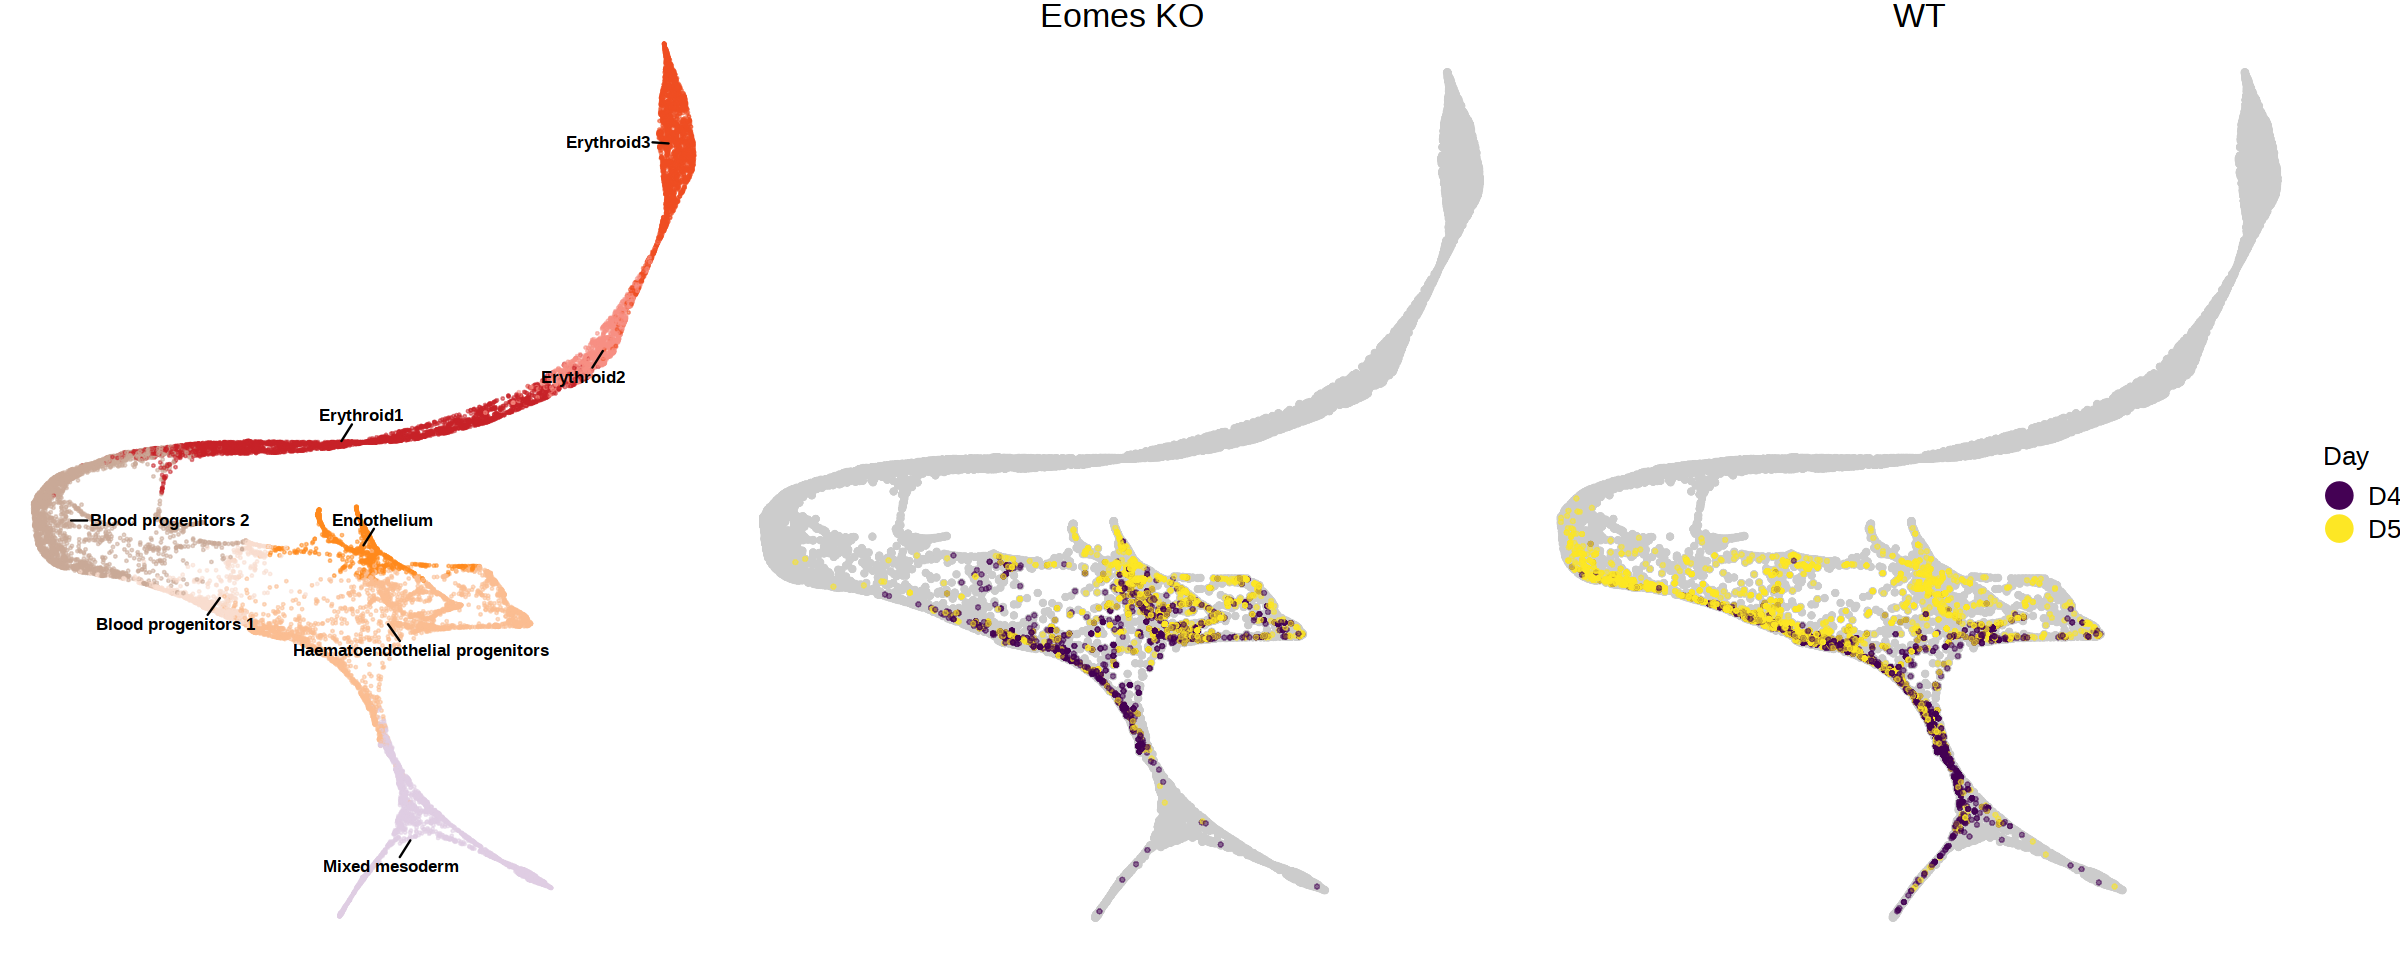

In [47]:
atlas = atlas_meta.dt[,c('cell', 'celltype','haem_gephiX', 'haem_gephiY'),] %>% setnames(c('haem_gephiX', 'haem_gephiY'), c('umapX','umapY'))
query = eomes_ncb_meta_full
    query_full = query %>%
                        merge(atlas[,c('cell', 'umapX', 'umapY')], by.x='closest.cell_ext', by.y='cell') %>% # add FA of closest cells
                        setnames(c('day'), c('Day'))    

    # Get labels at centre of group
    labels = atlas %>% 
                .[, N:=.N, by=celltype] %>% # number of cells per celltype
               # .[N>.N/100,] %>% # label only celltypes that are more than 1% of cells
                .[,list(median(umapX), median(umapY)), 
                        by=celltype] %>% # Determine median position on UMAP
                setnames(c('V1', 'V2'), c('umapX', 'umapY'))

    # Plot atlas FA
    p1 = ggplot(atlas, aes(umapX, umapY, col = celltype)) + 
        rasterise(geom_point(alpha = 0.5, size = 0.5), dpi=300) + 
        ggrepel::geom_text_repel(data=labels, 
                                    aes(umapX, umapY, label=celltype), 
                                    col='black', size = 3.5,
                                    max.overlaps=Inf, 
                                    fontface = "bold", 
                                    box.padding = 0.8, 
                                    show.legend = FALSE) + # adds text labels
        scale_color_manual(values=opts$celltype_ext.colors) + 
        theme_void() + 
        theme(text = element_text(size = 20), 
             legend.position='none')

    # Plot mapping
    p2 = ggplot(query_full, aes(umapX, umapY, col = Day)) + 
        rasterise(geom_point(data=atlas, aes(umapX, umapY), col='gray80'), dpi=300) + 
        rasterise(geom_point(alpha = 0.5, size = 1), dpi=500) +
        scale_color_viridis(discrete=TRUE) + 
        guides(colour = guide_legend(override.aes = list(size=7, alpha=1))) +
        facet_grid(~genotype) + 
        theme_void() + 
        theme(strip.text.x = element_text(size = 20),
              legend.title = element_text(size=15),
              legend.text = element_text(size=15))

    options(repr.plot.width=20, repr.plot.height=8)
    grid.arrange(p1, p2, ncol=2, widths = c(1,2.3))

### Celltype proportions

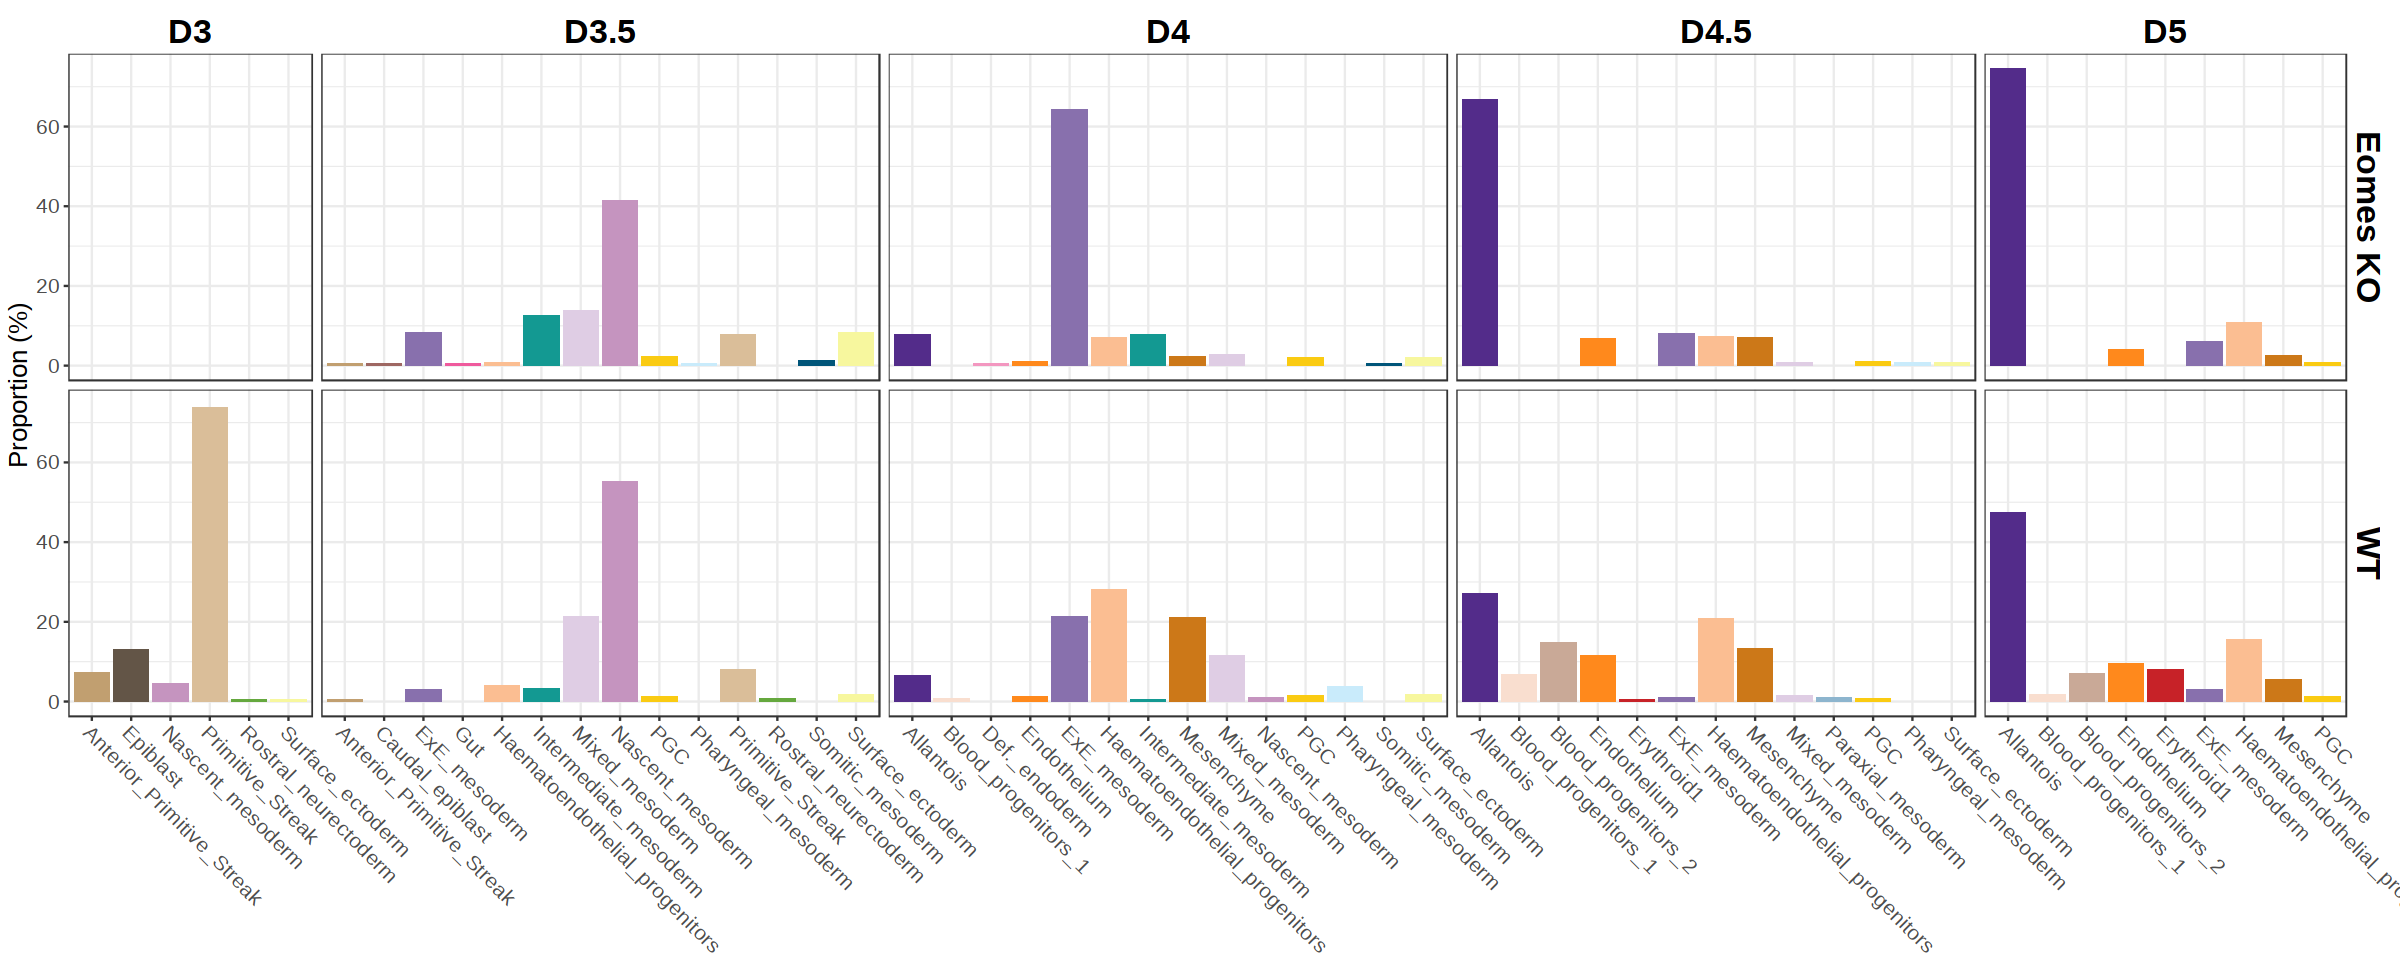

In [20]:
prop = as.data.table(table(eomes_multiome_meta$celltype, eomes_multiome_meta$genotype, eomes_multiome_meta$day)) %>%
    .[,prop:=N/sum(N)*100, by=c('V2', 'V3')]

p1 = ggplot(prop[prop>0.5,], aes(V1, prop, fill=V1)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=opts$celltype.colors) + 
    facet_grid(cols = vars(V3), rows = vars(V2), scales='free_x', space='free') + 
    ylab('Proportion (%)') + 
    theme_bw() + 
    theme(legend.position='none',
          text = element_text(size = 15, color='black'),
         axis.text.x = element_text(angle=-45, hjust=0),
         axis.title.x = element_blank(),
         strip.text.x = element_text(face='bold', size = 20, color='black'),
         strip.text.y = element_text(face='bold', size = 20, color='black'),
         strip.background = element_blank())
p1

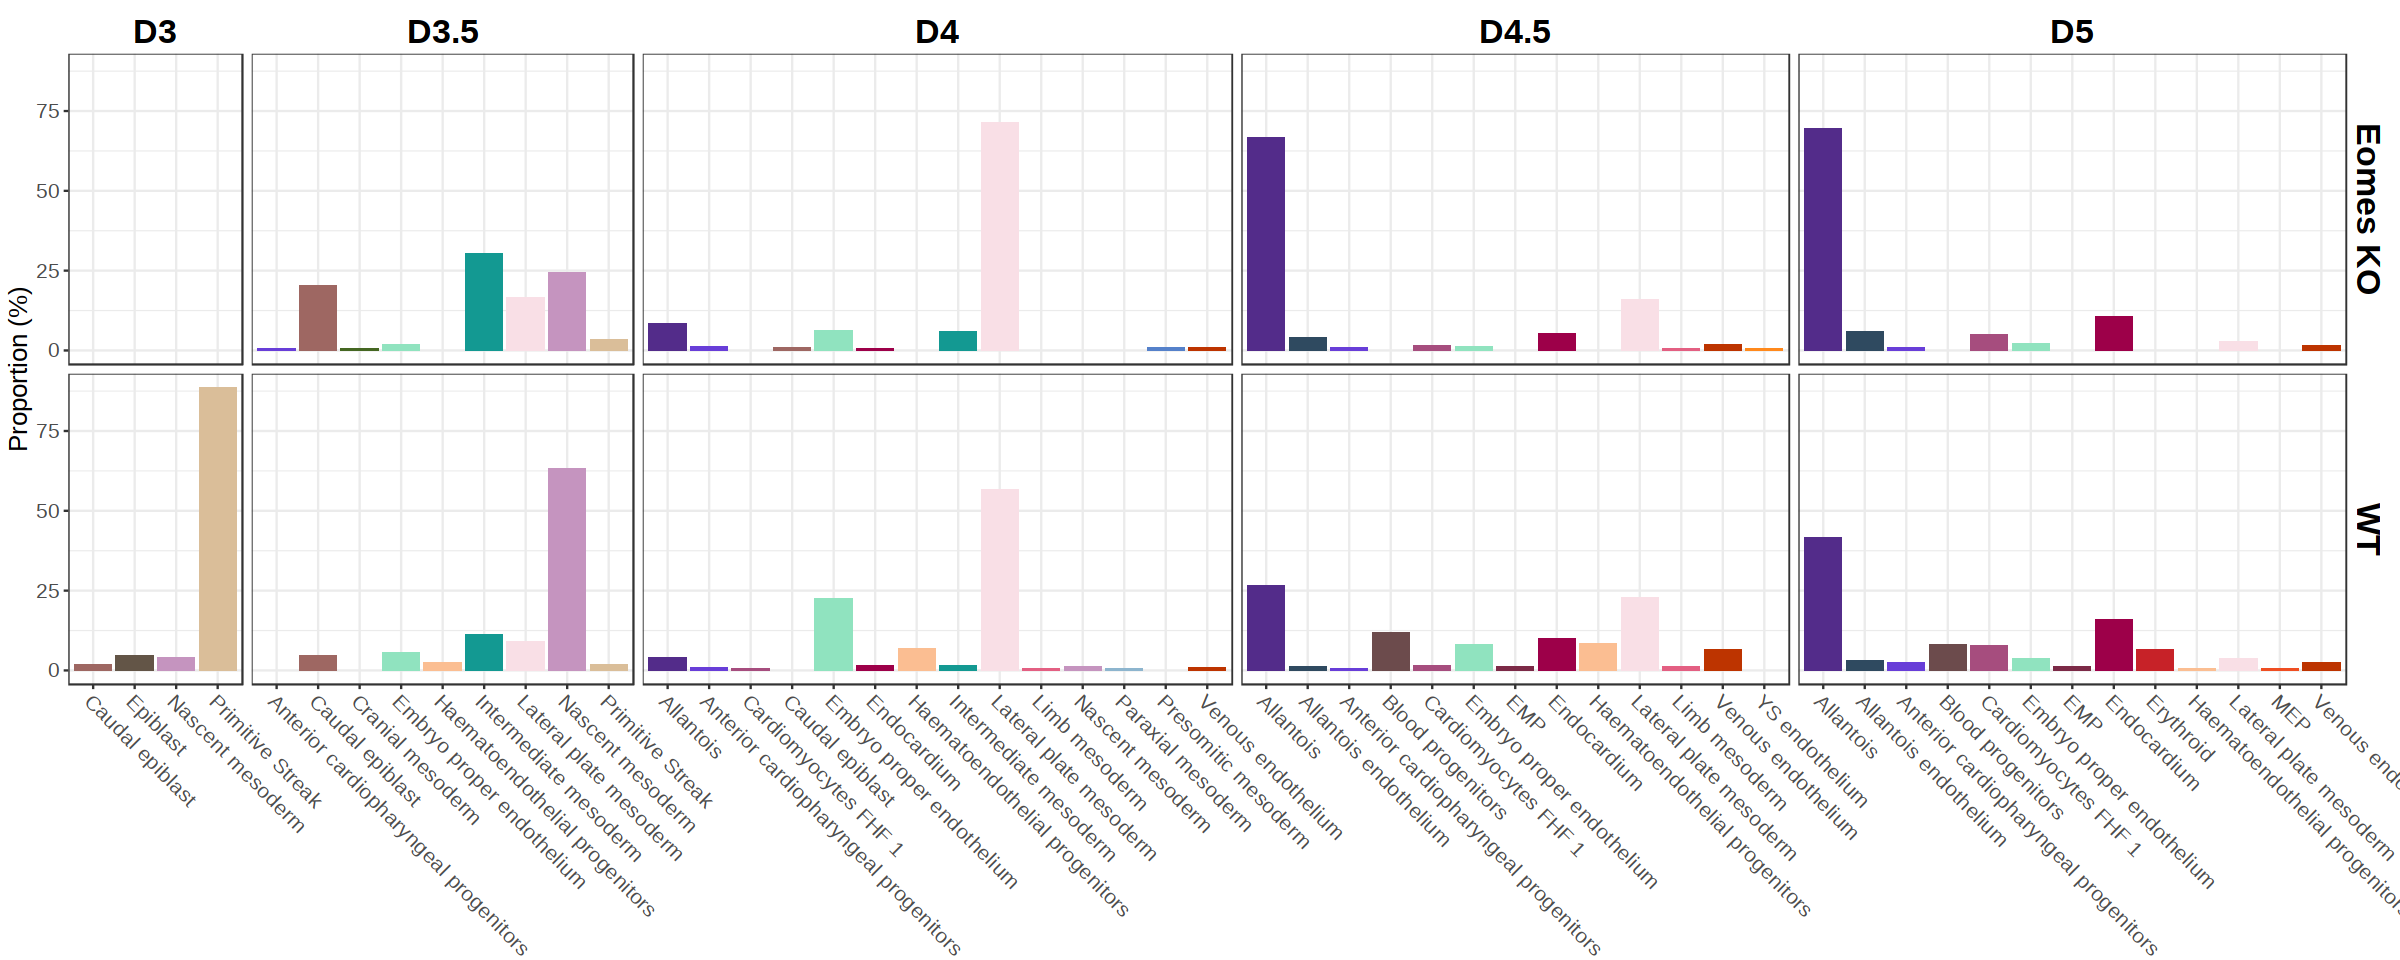

In [15]:
prop = as.data.table(table(eomes_multiome_meta$celltype.mapped_ext, eomes_multiome_meta$genotype, eomes_multiome_meta$day)) %>%
    .[,prop:=N/sum(N)*100, by=c('V2', 'V3')]

p1 = ggplot(prop[prop>0.5,], aes(V1, prop, fill=V1)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=opts$celltype_ext.colors) + 
    facet_grid(cols = vars(V3), rows = vars(V2), scales='free_x', space='free') + 
    ylab('Proportion (%)') + 
    theme_bw() + 
    theme(legend.position='none',
          text = element_text(size = 15, color='black'),
         axis.text.x = element_text(angle=-45, hjust=0),
         axis.title.x = element_blank(),
         strip.text.x = element_text(face='bold', size = 20, color='black'),
         strip.text.y = element_text(face='bold', size = 20, color='black'),
         strip.background = element_blank())
p1

In [16]:
pdf(file = file.path(io$plotdir, 'multiome_celltype_distribution_ext.pdf'),
    width=20, height=8)
        p1
dev.off()

png 
  2

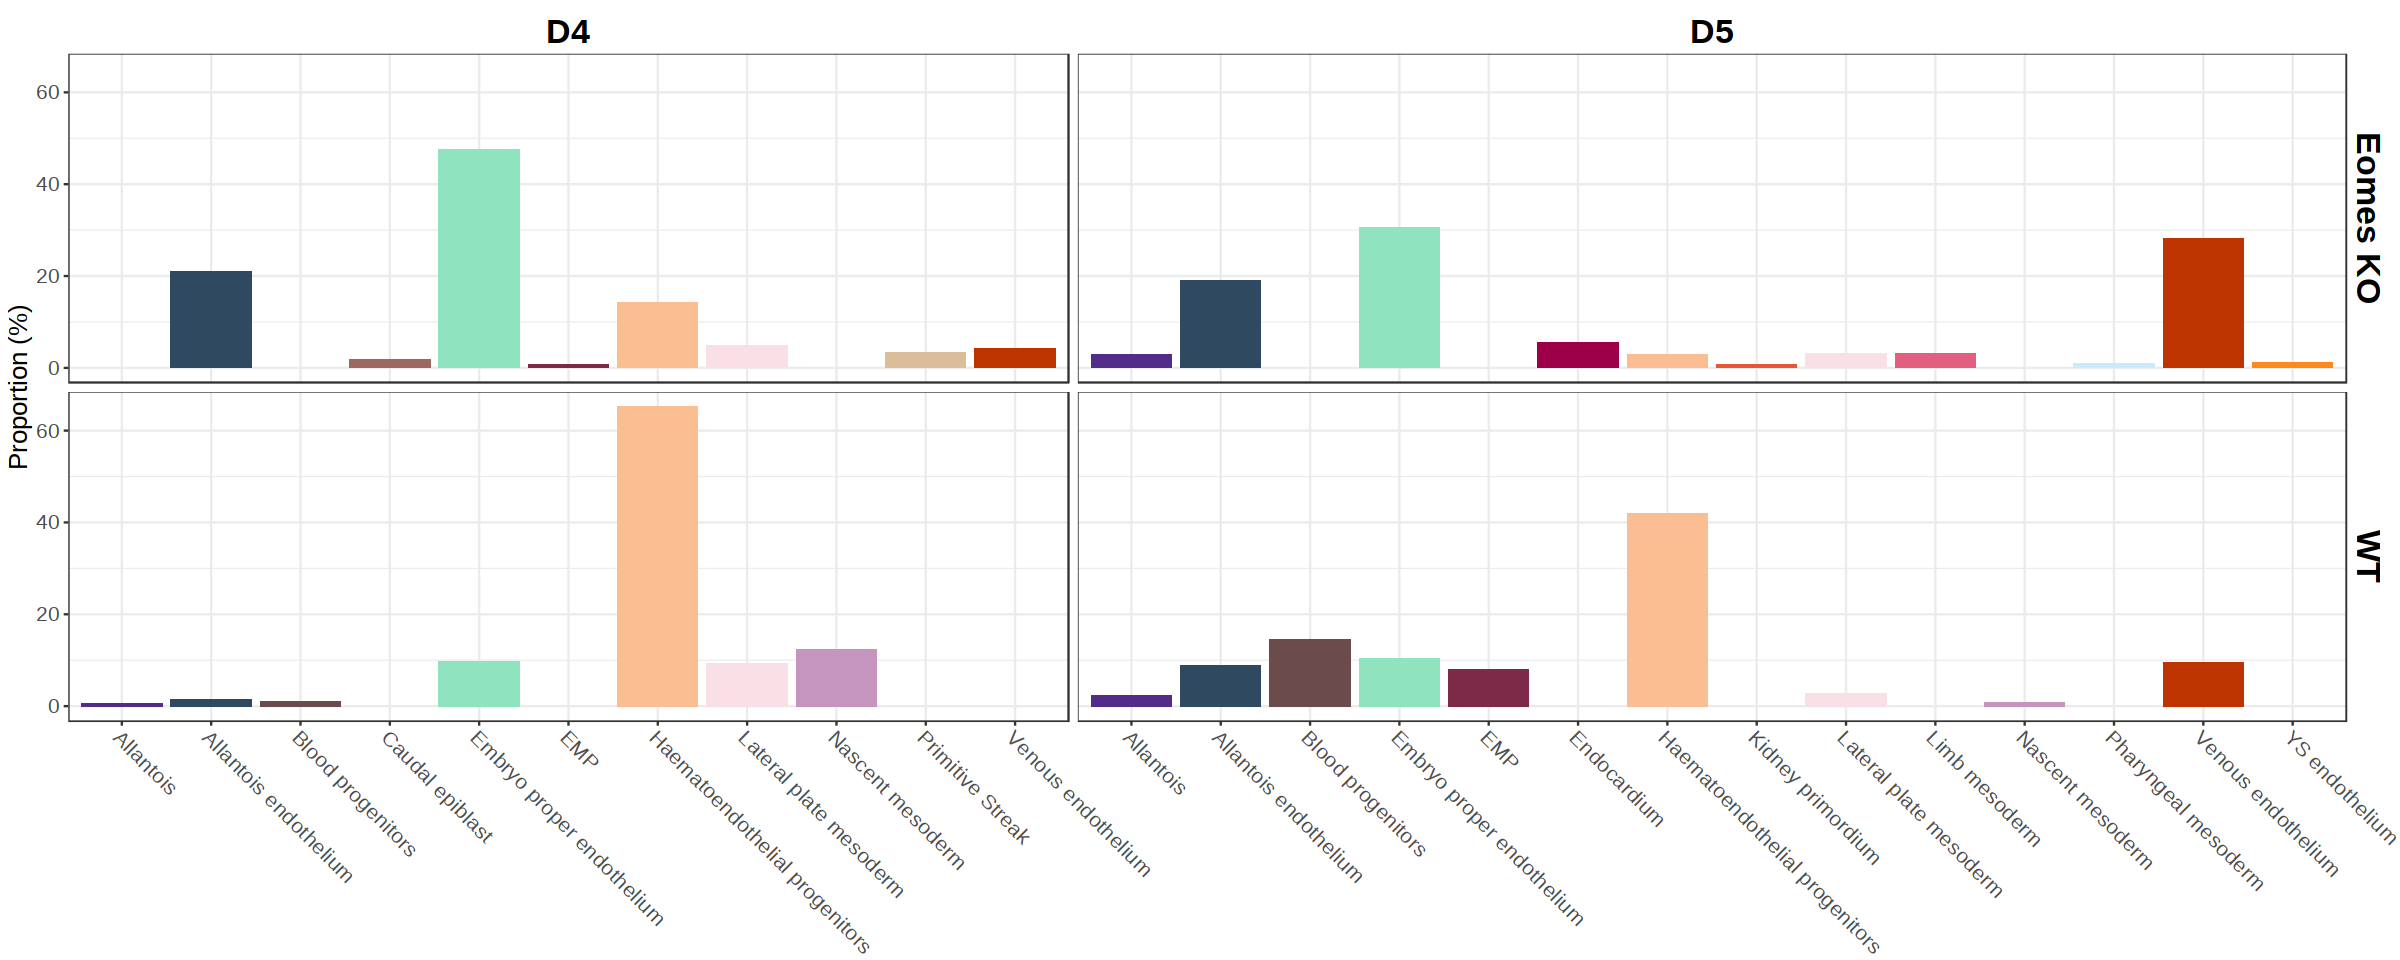

In [17]:
prop = as.data.table(table(eomes_ncb_meta_full$celltype.mapped_ext, eomes_ncb_meta_full$genotype, eomes_ncb_meta_full$day)) %>%
    .[,prop:=N/sum(N)*100, by=c('V2', 'V3')]

p2 = ggplot(prop[prop>0.5,], aes(V1, prop, fill=V1)) + 
    geom_bar(stat='identity') + 
    scale_fill_manual(values=opts$celltype_ext.colors) + 
    facet_grid(cols = vars(V3), rows = vars(V2), scales='free_x', space='free') + 
    ylab('Proportion (%)') + 
    theme_bw() + 
    theme(legend.position='none',
          text = element_text(size = 15, color='black'),
         axis.text.x = element_text(angle=-45, hjust=0),
         axis.title.x = element_blank(),
         strip.text.x = element_text(face='bold', size = 20, color='black'),
         strip.text.y = element_text(face='bold', size = 20, color='black'),
         strip.background = element_blank())

p2

In [18]:
pdf(file = file.path(io$plotdir, 'ncb_celltype_distribution_ext.pdf'),
    width=20, height=8)
        p2
dev.off()

png 
  2

#### Lukes grant UMAP

In [3]:
haem_full_landscape = readRDS(file.path(io$haem_landscape, "haem_full_landscape.rds"))

In [32]:
atlas = as.data.table(colData(haem_full_landscape))

In [33]:
colnames(atlas)

[1] "cell"                        "Dim1"                       
 [3] "Dim2"                        "sample"                     
 [5] "stage"                       "stage.mapped"               
 [7] "stage.collapsed"             "stage.mapped.collapsed"     
 [9] "somite_count"                "tube_name"                  
[11] "tube_name_corrected"         "celltype"                   
[13] "celltype.extended"           "celltype.descendant"        
[15] "celltype.descendant.somites" "doub.density"               
[17] "cluster"                     "cluster.sub"                
[19] "celltype.clustering"

In [34]:
unique(atlas$celltype.clustering)

[1] "Epiblast"                                      
 [2] "Primitive Streak"                              
 [3] "Non-neural ectoderm"                           
 [4] "Nascent mesoderm"                              
 [5] "Blood progenitors"                             
 [6] "Paraxial mesoderm"                             
 [7] "Lateral plate mesoderm"                        
 [8] "Intermediate mesoderm"                         
 [9] "Cardiopharyngeal progenitors SHF"              
[10] "Caudal epiblast"                               
[11] "Haematoendothelial progenitors"                
[12] "Cardiomyocytes FHF 1"                          
[13] "Allantois endothelium"                         
[14] "Erythroid"                                     
[15] "Embryo proper endothelium"                     
[16] "Anterior somitic tissues"                      
[17] "Cranial mesoderm"                              
[18] "Ectoderm"                                      
[19] "Anterior Primitive Streak"                     
[20] "Presomitic mesoderm"                           
[21] "Allantois"                                     
[22] "Mesenchyme"                                    
[23] "Node"                                          
[24] "EMP"                                           
[25] "Anterior cardiopharyngeal progenitors"         
[26] "Pharyngeal mesoderm"                           
[27] "Limb mesoderm"                                 
[28] "Venous endothelium"                            
[29] "Posterior somitic tissues"                     
[30] "Somitic mesoderm"                              
[31] "Dermomyotome"                                  
[32] "Caudal mesoderm"                               
[33] "Cardiopharyngeal progenitors FHF"              
[34] "Cardiomyocytes SHF 1"                          
[35] "Sclerotome"                                    
[36] "YS endothelium"                                
[37] "Kidney primordium"                             
[38] "NMPs"                                          
[39] "Endocardium"                                   
[40] "Epicardium"                                    
[41] "MEP"                                           
[42] "Embryo proper mesothelium"                     
[43] "Megakaryocyte progenitors"                     
[44] "Cardiopharyngeal progenitors"                  
[45] "YS mesothelium-derived endothelial progenitors"
[46] "Forelimb"                                      
[47] "Chorioallantoic-derived erythroid progenitors"

In [35]:
unique(atlas$tube_name)

[1] Undetermined head         torso        tail         YS          
[6] EP           anterior     posterior   
Levels: Undetermined anterior EP head posterior tail torso YS

In [38]:
atlas = atlas %>% .[celltype.clustering=='EMP',celltype.clustering:=ifelse(tube_name=='YS', 'EMP_YS', ifelse(tube_name=='EP', 'EMP_EP', 'EMP_atlas'))]

In [39]:
head(atlas)

cell,Dim1,Dim2,sample,stage,stage.mapped,stage.collapsed,stage.mapped.collapsed,somite_count,tube_name,tube_name_corrected,celltype,celltype.extended,celltype.descendant,celltype.descendant.somites,doub.density,cluster,cluster.sub,celltype.clustering
<fct>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
cell_1,-130760.95,-270247.8,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,0.0431142,7,5,Epiblast
cell_2,-93729.95,-238277.3,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Primitive Streak,Primitive Streak,Primitive Streak,Primitive Streak,1.1297133,7,6,Primitive Streak
cell_6,-139989.11,-261690.0,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.2547088,7,2,Epiblast
cell_8,-139573.60,-265925.3,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.3457586,7,1,Epiblast
cell_9,-132722.06,-271136.4,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.1463686,7,1,Epiblast
cell_10,-130816.86,-258119.0,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,0.0000000,7,7,Epiblast


In [40]:
embryo = c('Cranial mesoderm', 'Embryo proper endothelium', 'EMP_EP')#cranial mesoderm, and EP endothelium and EP EMPs
ExE = c('Lateral plate mesoderm', 'Allantois endothelium', 'YS endothelium', 'EMP_YS') #lateral plate mesoderm , allanotic mesdoerm and allanotic endothelium, YS endothelium and YS EMPs
atlas %>% .[,wave:= ifelse(celltype.clustering %in% embryo, 'Embryonic Wave', ifelse(celltype.clustering %in% ExE, 'ExE wave', 'atlas'))]

In [26]:
head(labels)

wave,Dim1,Dim2
<chr>,<dbl>,<dbl>
atlas,48294.81,-52824.92
ExE wave,-113755.63,-46832.94
Embryonic Wave,-37107.74,-36730.86


In [49]:
p = ggplot(atlas, aes(Dim1, Dim2, col = wave)) + 
        rasterise(geom_point(alpha = 0.5, size = 0.5), dpi=300) + 
        scale_color_manual(values=c('gray80', 'blue', 'red')) + 
        guides(colour = guide_legend(override.aes = list(size=2, alpha = 1))) +
        theme_void() + 
        theme(text = element_text(size = 20))

pdf(file = file.path(io$plotdir, 'haem_landscape_waves.pdf'),
    width=10, height=8)
        p
dev.off()

png 
  2